# Systemy uczące się - Zad. dom. 2: Maszyny wektorów podpierających

### Autor rozwiązania
Uzupełnij poniższe informacje umieszczając swoje imię i nazwisko oraz numer indeksu:

In [1]:
NAME = "Jakub Bilski"
ID = "155865"

Ten notebook zawiera zadania związane z maszynami wektorów podpierających (SVM).
Do notebooka zostały dołączony plik helpers.py oraz dwa pliki .npz z danymi, które są używane w zadaniach,
nie musisz do nich zaglądać ani ich modyfikować. Notebook jest sprawdzany półautomatycznie - przed wysyłką sprawdź czy cały kod wykonuje się bez błędów.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

## Zadanie 1. - Implementacja maszyny wektorów podpierających (za 20%)

Zadanie polega na zaimplementowaniu maszyny wektorów podpierających z wykorzystaniem biblioteki [`cvxpy`](https://github.com/cvxpy/cvxpy) zapewniającej solver do programowania kwadratowego. Rozpocznijmy od szybkiej nauki jak ta biblioteka działa:


In [3]:
!pip install cvxpy

- Optymalizacja bez ograniczeń: znajdź maksimum funkcji $$ - (x - 5 )^2 + 10$$

In [4]:
from cvxpy import Variable, Maximize, Problem

x = Variable(1)  #zmienna optymalizowana, wektor o długości 1 (bo to jedna liczba)

objective = Maximize(-(x - 5) ** 2 + 10)  # Implementacja funkcji celu ze wskazanym kierunkiem maksymalizacji
prob = Problem(objective)  # Stworzenie problemu optymalizacji

print(prob.solve())  #Rozwiąż i zwróć wartość funkcji celu
print(x.value)  # Znaleziona wartość x
print(prob.status)

10.0
[5.]
optimal


- optymalizacja z ograniczeniami: znajdź minimum funkcji $e^{(x-2)^2}$ dla $x>0$.

In [5]:
from cvxpy import exp, Minimize

x = Variable(1)

objective = Minimize(exp((x - 2) ** 2))
constraints = [x >= 0]
prob = Problem(objective, constraints)  # Problem teraz składa się z funkcji celu i "listy" ograniczeń

print(prob.solve())
print(x.value)
print(prob.status)

1.000000000109397
[2.00001046]
optimal


- optymalizacja z ograniczeniami: znajdź minimum funkcji $x + y$ dla $x\geq 0, y\geq 6$.

In [6]:
from cvxpy import Minimize

x = Variable(1)
y = Variable(1)

objective = Minimize(x + y)
constraints = [x >= 0, y >= 6]  # To zwykła pythonowa lista
prob = Problem(objective, constraints)  # Problem teraz składa się z funkcji celu i listy ograniczeń

print(prob.solve())
print(x.value, y.value)
print(prob.status)

6.000000000000001
[6.06639057e-17] [6.]
optimal


Alternatywna postać tego samego problemu, wykorzystująca notację wektorową:

In [7]:
x = Variable(2)

objective = Minimize(sum(x))
constraints = [x[0] >= 0, x[1] >= 6]
prob = Problem(objective, constraints)  # Problem teraz składa się z funkcji celu i listy ograniczeń

print(prob.solve())
print(x.value)
print(prob.status)

6.000000000000001
[6.06639057e-17 6.00000000e+00]
optimal


Wygenerujmy i narysujmy próbkę dwuwymiarowych danych, które są separowalne liniowo. Zwróć uwagę, że dla uproszczenia przyszłej implementacji każda z cech jest przechowywana w osobnym wektorze. Wektor `x` zawiera wartości pierwszej cechy, wektor `y` zawiera wartości drugiej cechy, a `labels` zawiera wartości klasy decyzyjnej.

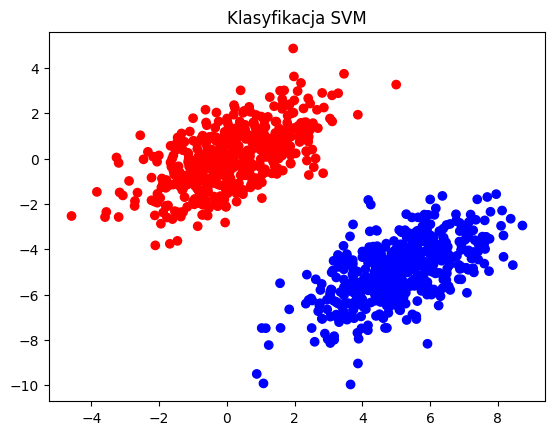

In [8]:
from helpers import plot_classification, get_separable

x, y, labels = get_separable()
plot_classification(x, y, labels)

Mamy dane pochodzące z dwóch klas, a nasze zadanie polega na implementacji klasyfikatora SVM czyli indukcji (w naszym dwuwymiarowym przypadku) linii któa będzie separowała obie klasy.
$$a \cdot x+b \cdot y +c = 0$$
Klasyfikator będzie przypisywał obiekt do jednej z klas gdy będzie się on znajdował po prawej stronie tej linii, jeśli zaś obiekt będzie po lewej jej stronie to przypiszemy obiekt do drugiej z klas. Znajdź taką linię dla powyższych danych, gdzie `x` i `y` to współrzędne punktów, a `labels` przyjmuje wartości $1$ i $-1$ wskazując na klasę obserwacji.

In [13]:
def construct_svm_opt_problem(x: np.ndarray, y: np.ndarray, labels: np.ndarray) -> Problem:
    """Funkcja budująca problem optymalizacji dla klasyfikatora SVM (hard margin).

    Args:
        x (np.ndarray): Współrzędne x obiektów
        y (np.ndarray): Współrzędne y obiektów
        labels (np.ndarray): Klasy obiektów

    Returns:
        Problem: Obiekt problemu optymalizacyjnego dla klasyfikatora SVM

    """

    a, b, c = Variable(), Variable(), Variable()

    function = Minimize(1/2 * (a**2 + b**2))
    constraints = [labels[i] * (x[i]*a + y[i]*b + c) >=1
                   for i in range(len(labels))]

    return Problem(function, constraints)


prob = construct_svm_opt_problem(x, y, labels)
prob.solve()
prob.status

'optimal'

Jeśli dobrze wytrenowałeś klasyfikator to powinno się udać go narysować.

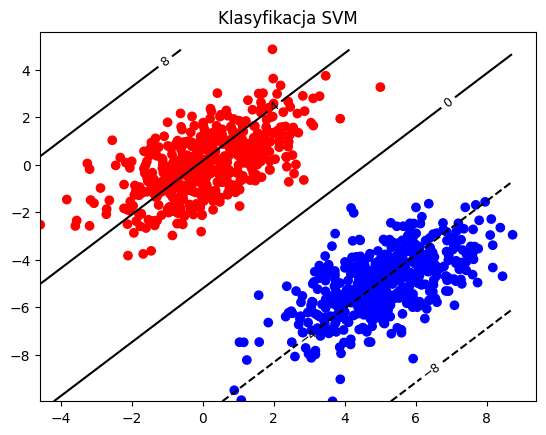

In [14]:
a, b, c = prob.variables()
plot_classification(x, y, labels, a=a.value, b=b.value, c=c.value)

Przejdźmy na trudniejszy zbiór, który nie jest liniowo separowalny.

**UWAGA** Dane są losowane - istnieje mała szansa, że akurat wylosujesz zbiór separowalny. W takiej sytuacji powtórz wywołanie.

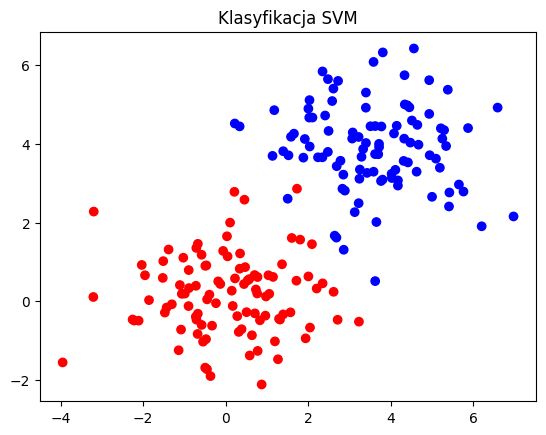

In [24]:
from helpers import plot_classification, get_non_separable

x, y, labels = get_non_separable()
plot_classification(x, y, labels)

Rozszerz swoją implementację klasyfikatora SVM tak aby prawidłowo działał również ze zbiorami nieliniowo separowalnymi. Za stałą $C$ możesz przyjąć 1.

In [26]:
def construct_softsvm_opt_problem(x: np.ndarray, y: np.ndarray, labels: np.ndarray, C: int = 1) -> Problem:
    """Funkcja budująca problem optymalizacji dla klasyfikatora SVM (soft margin).

    Args:
        x (np.ndarray): Współrzędne x obiektów
        y (np.ndarray): Współrzędne y obiektów
        labels (np.ndarray): Klasy obiektów
        C (int): Stała C

    Returns:
        Problem: Obiekt problemu optymalizacyjnego dla klasyfikatora SVM

    """

    a = Variable(name="a")
    b = Variable(name="b")
    c = Variable(name="c")
    eta = Variable(len(labels), name="eta")

    function = Minimize(1/2 * (a**2 + b**2) + C*sum(eta))
    constraints = [
        labels[i] * (x[i] * a + y[i] * b + c) >= 1 - eta[i]
        for i in range(len(labels))
    ] + [eta >= 0]

    return Problem(function, constraints)


prob = construct_softsvm_opt_problem(x, y, labels)
prob.solve()
prob.status

'optimal'

Narysuj nauczony klasyfikator.

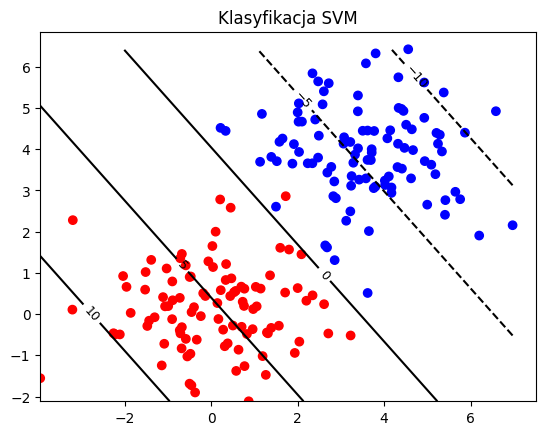

In [27]:
vars_dict = {v.name(): v for v in prob.variables()}
plot_classification(x, y, labels,
                    a=float(vars_dict["a"].value),
                    b=float(vars_dict["b"].value),
                    c=float(vars_dict["c"].value))

## Zadanie 2. - Eksploracja liniowego SVM (za 20%)

Wczytaj dane liniowo sepratowalne gdzie `X` to macierz cech, a `y` zwiera wartości klasy decyzyjnej.

In [28]:
from helpers import get_separable

x, y = get_separable(True)

Wytrenuj model maszyn wektorów podpierających używając obiektu SVC (Support Vector Classifier) z biblioteki `sklearn`. Konstruktor tego obiektu ma parametr `kernel` który domyślnie jest ustawiony na jądro RBF, początkowo będziemy chcieli używać wersji klasyfikatora bez jądra czyli inaczej z jądrem liniowym - ustaw ten parametr na wartość `"linear"`.

In [29]:
from sklearn.svm import SVC

model = SVC(kernel='linear')
model.fit(x, y)

SVC(kernel='linear')

Kolejnym krokiem będzie narysowanie granicy decyzji. Funkcję możesz implementować przyrostowo, punkt po punkcie.
1. Niech funkcja narysuje dane uczące (x,y) zaznaczając kolorem klasy decyzyjne.
2. Zaznacz na wykresie granicę decyzji. Wytrenowany SVM (obiekt SVC) ma odpowiednie wartości nauczonych współczynników we właściwości `svm.coef_` a także wyraz wolny w `svm.intercept_`<br>
    *Wskazówka*: Zwróć uwagę, że linię separującą o wzorze
    $w_0*x_0 + w_1*x_1 + b = 0$ można przekształcić do postaci:
    $$x_1= -\frac{w_0}{w_1}  x_0 - \frac{b}{w_1} $$
3. Zaznacz na wykresie margines decyzji (np. poprzez narysowanie dwóch linii równoległych do granicy decyzji w odpowiedniej odległości). Przypomnij sobie, że z naszych wyprowadzeń wynika że wartość marginesu to $\frac{1}{||w||}$
4. Zakreśl specjalnym symbolem lub podświetl elementy zbioru uczącego będącymi wektorami podpierającymi. Ich współrzędne możesz odnaleźć we właściwości `svm.support_vectors_`

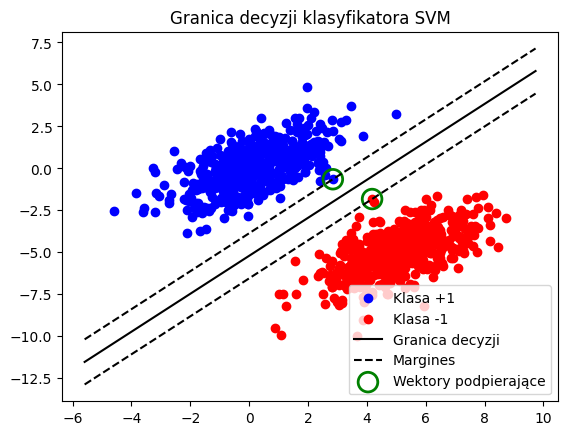

In [30]:
def plot_svm(svm: SVC, x: np.ndarray, y: np.ndarray) -> None:
    """Funkcja rysująca granicę decyzji klasyfikatora SVM.

    Args:
        svm (SVC): Wytrenowany klasyfikator SVM
        x (np.ndarray): Cechy
        y (np.ndarray): Klasy

    Returns:
        None
    """
    w = svm.coef_[0] # [w0, w1]
    b = svm.intercept_[0] # bias

    # punkty danych
    plt.scatter(x[y == 1, 0], x[y == 1, 1], c='blue', label='Klasa +1')
    plt.scatter(x[y == -1, 0], x[y == -1, 1], c='red', label='Klasa -1')

    x0_vals = np.linspace(x[:, 0].min() - 1, x[:,0].max() + 1, 200)

    # granica decyzji: w0x0 + w1x1 + b = 0
    # po przekształceniu: x1 = -(w0/w1)x0 - b/w1
    decision = -(w[0]/w[1]) * x0_vals - b/w[1]

    # marginesy: w0x0 + w1x1 + b = +- 1
    # przekształcone do postaci x1 = - (w0/w1)x0 - (b+-1)/w1
    margin_pos = -(w[0]/w[1]) * x0_vals - (b - 1) / w[1]
    margin_neg = -(w[0]/w[1]) * x0_vals - (b + 1) / w[1]

    plt.plot(x0_vals, decision, 'k-', label='Granica decyzji')
    plt.plot(x0_vals, margin_pos, 'k--', label='Margines')
    plt.plot(x0_vals, margin_neg, 'k--')


    plt.scatter(svm.support_vectors_[:,0], svm.support_vectors_[:,1], s=200,
                facecolors='none', edgecolors='green', linewidths=2, label='Wektory podpierające')

    plt.legend()
    plt.title('Granica decyzji klasyfikatora SVM')
    plt.show()

plot_svm(model, x, y)

Zwróć uwagę na granicę decyzji, narysowany margines oraz podświetlone obiekty będące wektorami podpierającymi.

Wczytaj nowy zbiór danych

In [34]:
dane = np.load('data_outlier.npz')
x = dane['X']
y = dane['y'].reshape(-1)
y = np.where(y == 0, -1, 1) #poprawka przy ładowaniu danych

In [35]:
print(np.unique(y))
print(np.sum(y == 1), np.sum(y == -1))

[-1  1]
21 30


oraz powtórz poprzednią procedurę tj. wytrenuj klasyfikator oraz narysuj wykres.

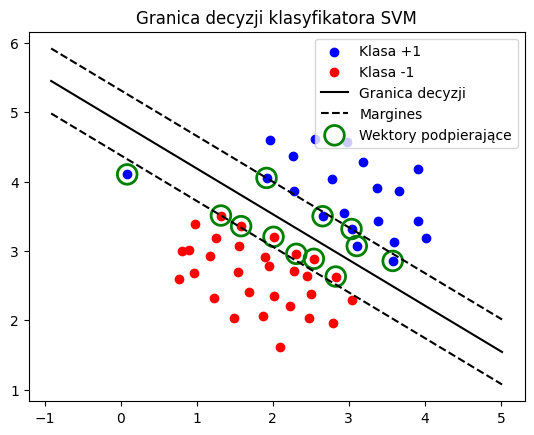

In [37]:
model = SVC(kernel='linear')
model.fit(x, y)
plot_svm(model, x, y)

W `sklearn` klasyfikator SVM ma domyślną wartość parametru $C = 1.0$. Zbiór jest jednak liniowo separowalny - sprawdź jak wygląda granica decyzji z innymi wartościami $C$ a w szczególności z wartością `C = float("inf")`. Wartość $C$ jest parametrem konstruktora obiektu SVC.

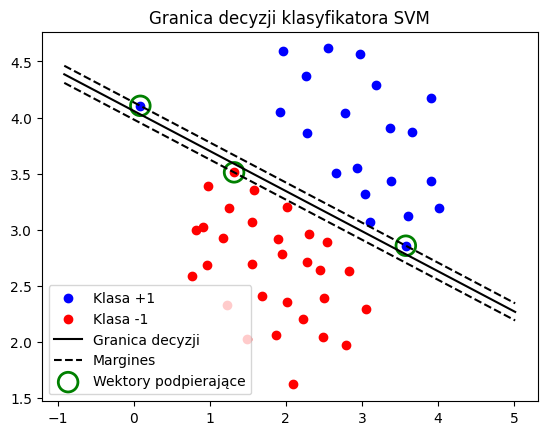

In [38]:
model = SVC(kernel='linear', C=float('inf'))
model.fit(x, y)
plot_svm(model, x, y)

Wypróbuj różne wartości parametru $C$ na zbiorze nieseparowalnym liniowo.

In [39]:
from helpers import get_non_separable

x, y = get_non_separable(True)

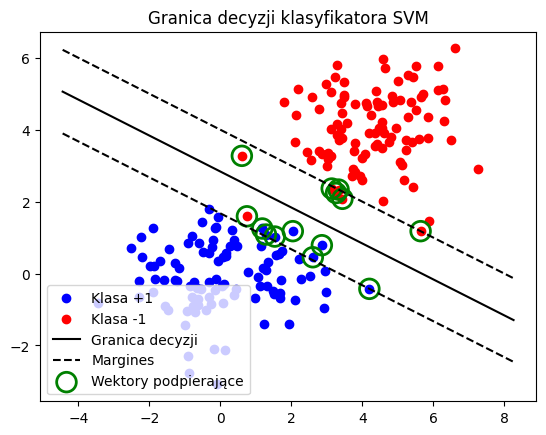

In [40]:
model = SVC(kernel='linear', C=0.1)
model.fit(x, y)
plot_svm(model, x, y)

**Polecenia**
1. Jak zmienia się wyindukowana granica decyzji dla bardzo dużych ($\infty$) i bardzo małych (np. 0.01) wartości $C$? Jak zmienia się trafność klasyfikatora na zbiorze uczącym? Jak sądzisz, która granica decyzja będzie najlepsza na zbiorze testowym?
2. Jak zmienia się liczba wektorów podpierających wraz ze zmianą $C$? Liczba wektorów podpierających jest miarą złożoności hipotezy - jakie wartości $C$ powodują bardziej złożone hipotezy? Odnieś te rozważania do przetargu wariancja - obciążenie.
3. Czy klasyfikator SVM jest klasyfikatorem który może zwrócić prawdopodobieństwo przynależności do klas? Czy jest to klasyfikator generatywny czy dyskryminacyjny?

Odpowiedz na powyższe pytania:

1. Im większe C, tym węższe marginesy, ponieważ model stara się minimalizować naruszenia, wymuszając sumę eta_i = 0. Następuje degeneracja do optymalizacji w wersji hard. Accuracy na zbiorze treningowym będzie lepsze, ale to bardzo prosta droga do overfittingu. Z kolei im mniejsze C, to model bardziej skupia się na maksymalizacji marginesu i toleruje coraz więcej naruszeń, przez co acc jest niższe i dochodzi do underfittingu. Dobra wartość C to taka, która nie doprowadza do sytuacji, w której jakiś z członów (połowa kwadratu normy wag lub suma naruszeń) nie dominuje, nie wpływa mocno na proces optymalizacji. Można dobrać ją np. przez cross-validation.

2. Im większe C, tym mniej wektorów podpierających, bo coraz mniej punktów mieści się dokładnie na marginesie. Duża kara za błędy, model stara się omijać outliery. Zmiana w zbiorze treningowym zatem drastyczniej przesuwa granicę, czyli mamy do czynienia z dużą wariancją. Z mniejszym C z kolei w drugą stronę. Im mniej wektorów podpierających (im większe C), tym bardziej złożona hipoteza.

3. SVM w standardowej wersji nie zwraca prawdopodobieństw przynależności do klasy, ale wartość funkcji decyzyjnej, czyli odległość (nieznormalizowaną, bo bez dzielenia przez normę) punktu od hiperpłaszczyzny rozdzielającej. Istnieje jednak technika Platt scaling, w której surowe wyniki z SVM nakłada się na dodatkowy model regresji logistycznej i mapuje się te odległości na wartości od 0 do 1. SVM to klasyfikator dyskryminacyjny, ponieważ skupia się na znalezieniu twardej granicy, która najlepiej oddziela od siebie klasy. W procesie uczenia nie ma modelowania rozkładu prawdopodobieństwa.

## Zadanie 3. - Trik jądrowy (za 20%)
Klasyfikator SVM, który jest liniowy jest dość mocno ograniczony. Nie będzie potrafił m.in. prawidłowo zaklasyfikować przedstawionego zbioru.

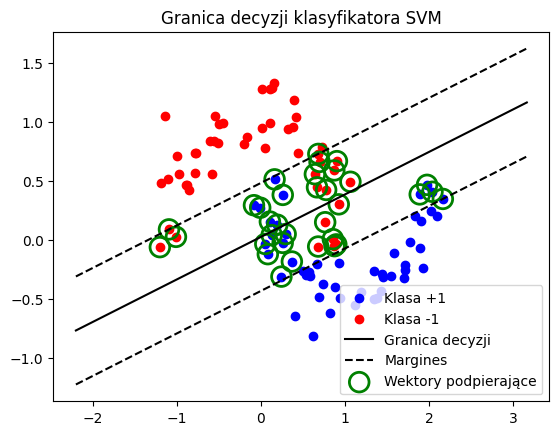

In [42]:
from sklearn.datasets import make_moons

x, y = make_moons(n_samples=100, noise=0.15, random_state=2024)
y = np.where(y == 0, -1, 1)

model = SVC(kernel="linear")
model.fit(x, y)
plot_svm(model, x, y)

Problem ten można rozwiązać podobnie jak w przypadku regresji logistycznej: poprzez dodawanie dodatkowych cech. Na zajęciach z regresji dodawaliśmy cechy wielomianowe: spróbuj tego tricku również teraz wykorzystując obiekt `Pipeline` oraz `PolynomialFeatures` z cechami stopnia 3.

**Uwaga**: do rysowania wykresu trzeba teraz użyć funkcji `plot_classifier`.

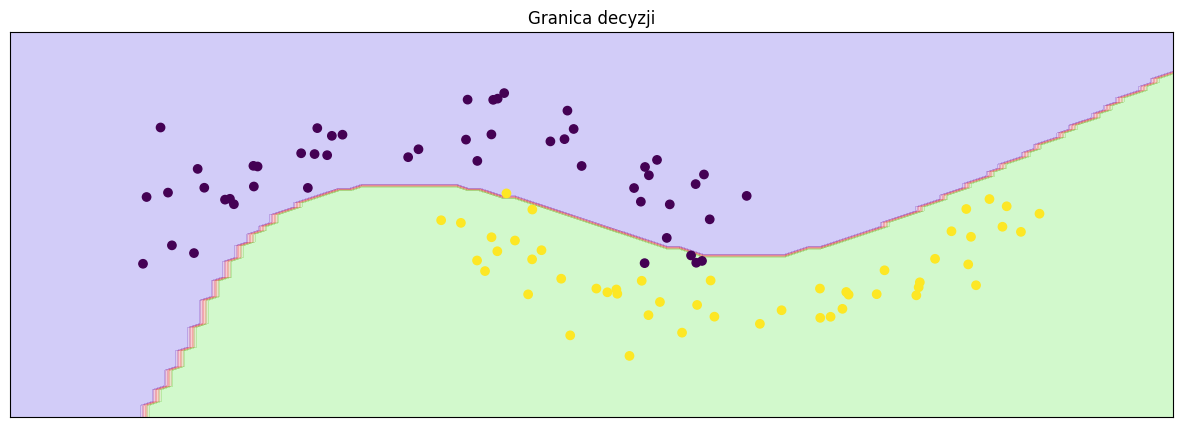

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from helpers import plot_classifier

pipeline = Pipeline([
    ('cubic features', PolynomialFeatures(degree=3, include_bias=False)),
    ('svc', SVC(kernel='linear'))
])

#call the pipeline
pipeline.fit(x, y)
plot_classifier(x, y, pipeline)

Tak jak dyskutowaliśmy na laboratoriach (i wykładzie) tego typu operacja dla zbiorów które mają nawet niezbyt dużo cech może wygenerować bardzo dużo cech. Dla przykładu rozważając zbiór z tysiącem cech i generację cech wielomianowych tylko *drugiego* rzędu (czyli de facto najniższego nieliniowego) spowoduje dodanie prawie pół miliona cech! Nie mniej jednak kernel (jądro) takiej operacji jest wyrażone wzorem:
$(x^Ty + 1 )^2$ i można je obliczyć w czasie liniowym od liczby oryginalnych cech (tutaj 1000)!

W obiekcie SVC możemy wykorzystać jądro wielomianowe specyfikując `kernel="poly"` oraz ew. podając dodatkowe parametry `degree` oraz `coef0`. Co oznaczają te parametry? Jądro wielomianowe jest wyrażone wzorem:
$$K(x,y) = (x^\mathsf{T} y + c)^{d}$$
gdzie $d$ to właśnie `degree`, a stała $c$ to `coef0`. Zmienna $d$ ma bardzo prostą interpretację: jest to stopień wielomianu. Stała $c$ ma natomiast szczególne znaczenie: jeśli jest ona równa $c=0$ to kernel generuje wszystkie jednomiany rzędu $d$ (jądro wielomianowe homogeniczne), jeżeli $c=1$ to kernel generuje wszystkie jednomiany rzędu co najwyżej $d$. Dodatkowo stała $c$ może być też strojona (ale w praktyce raczej rzadko się to robi)  ponieważ reguluje ona przetarg między wpływem cech wyższego rzędu a wpływem cech rzędu niższego. Stała $c$ nie może być ujemna.

Wykorzystaj jądro wielomianowe do klasyfikacji badanego zbioru. (Pamiętaj o wyelimiowaniu dodawania cech wielomianowych!)

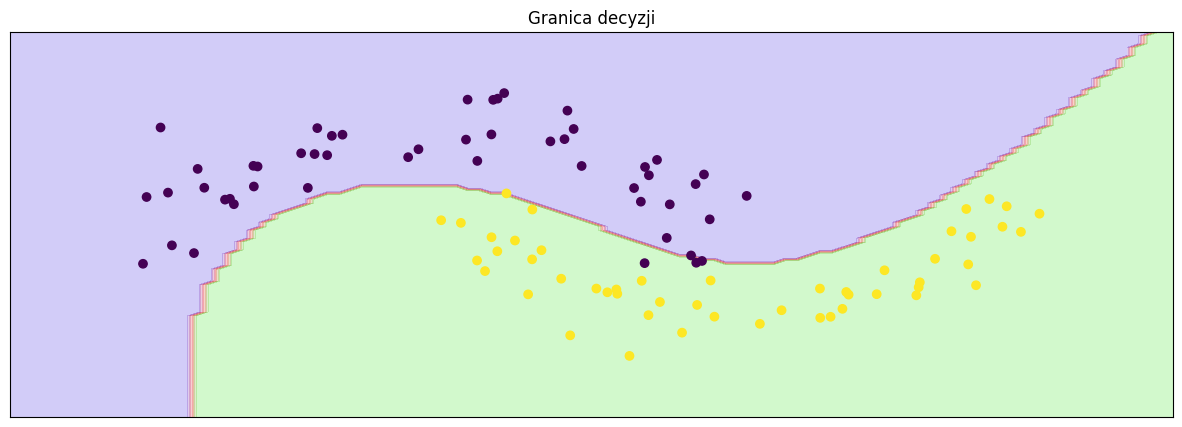

In [44]:
from helpers import plot_classifier

model = SVC(kernel='poly', coef0=1)
model.fit(x, y)
plot_classifier(x, y, model)

SVM z jądrami może sobie teraz poradzić także z problemem XOR. Wygenerujmy takie dane:

In [53]:
x = np.random.randn(200, 2)
y = np.logical_xor(x[:, 0] > 0, x[:, 1] > 0)

i wytrenuj klasyfikator. Spróbuj pozmieniać wartość kontrolującą złożoność hipotezy $C$ (nie jest to $c$ z funkcji jądra!).

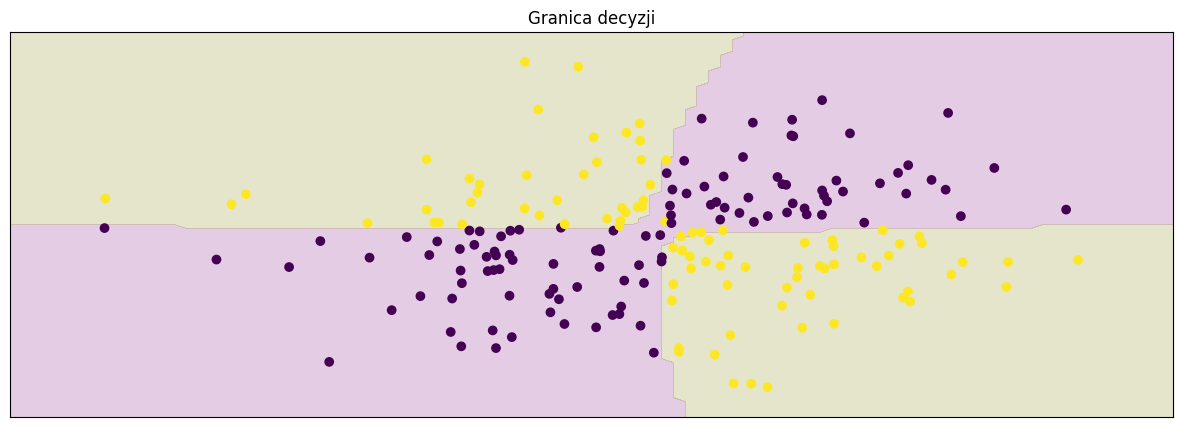

In [54]:
model = SVC(kernel='poly', coef0=1)
model.fit(x, y)
plot_classifier(x, y, model)

Posteruj parametrami `degree` i `C` dla problemu XOR oraz wcześniejszego problemu klasyfikacji (dwa księżyce).

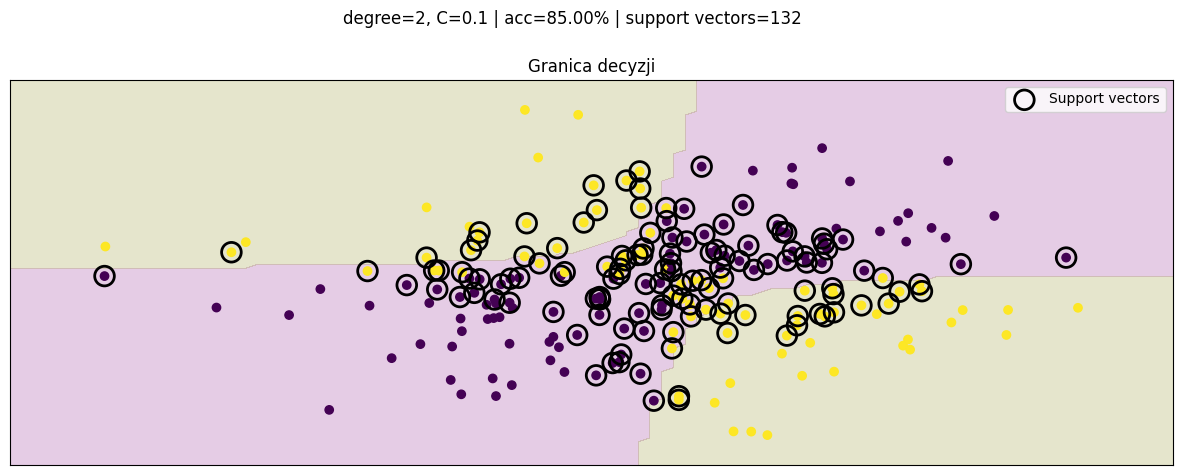

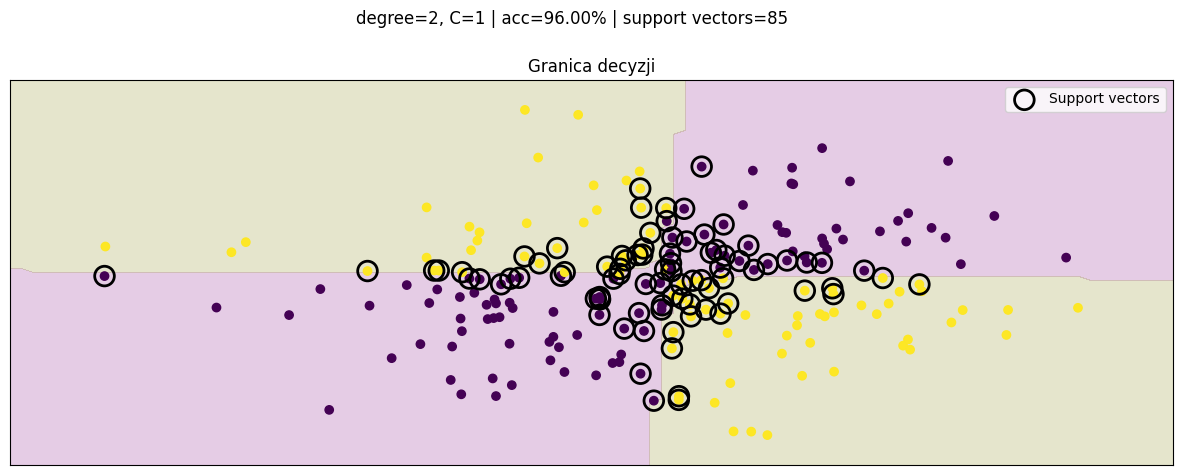

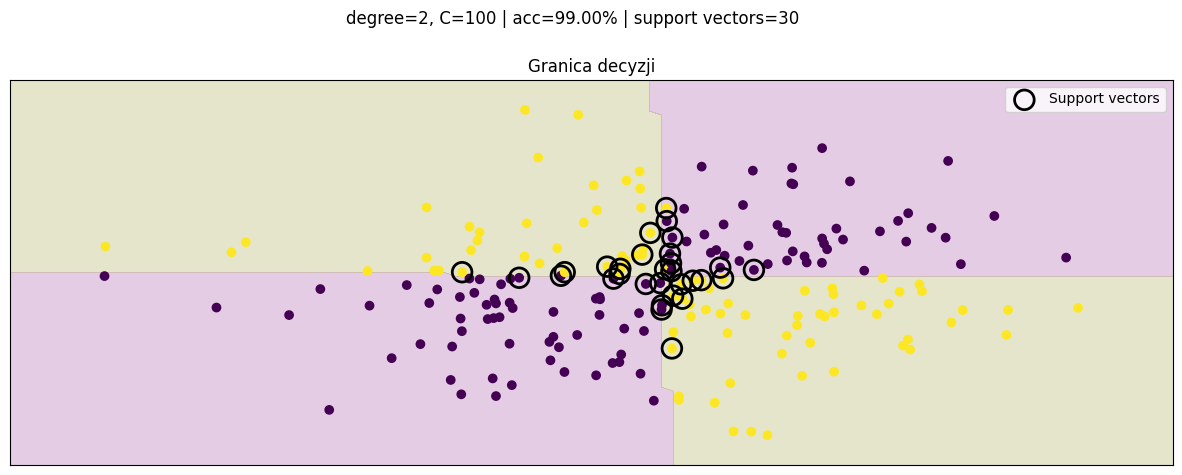

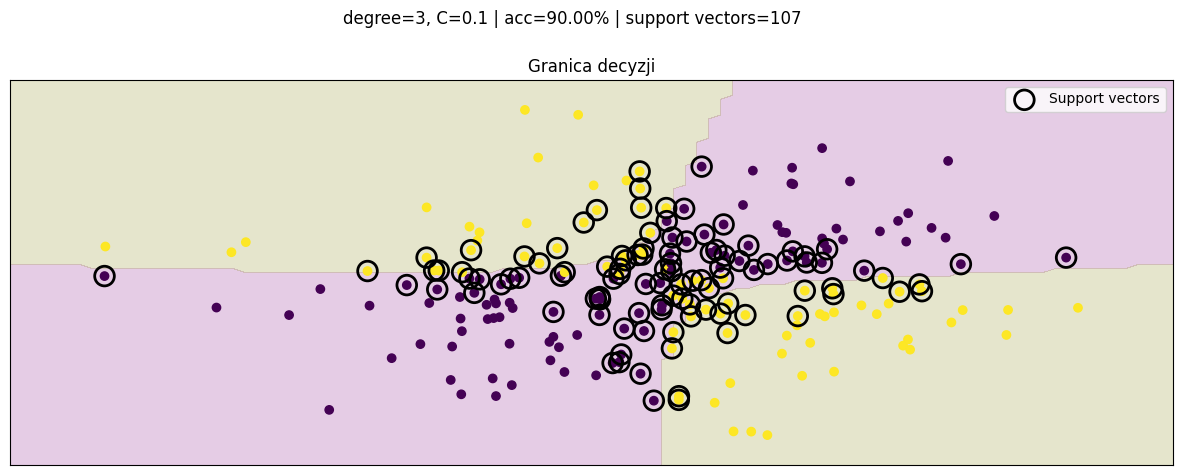

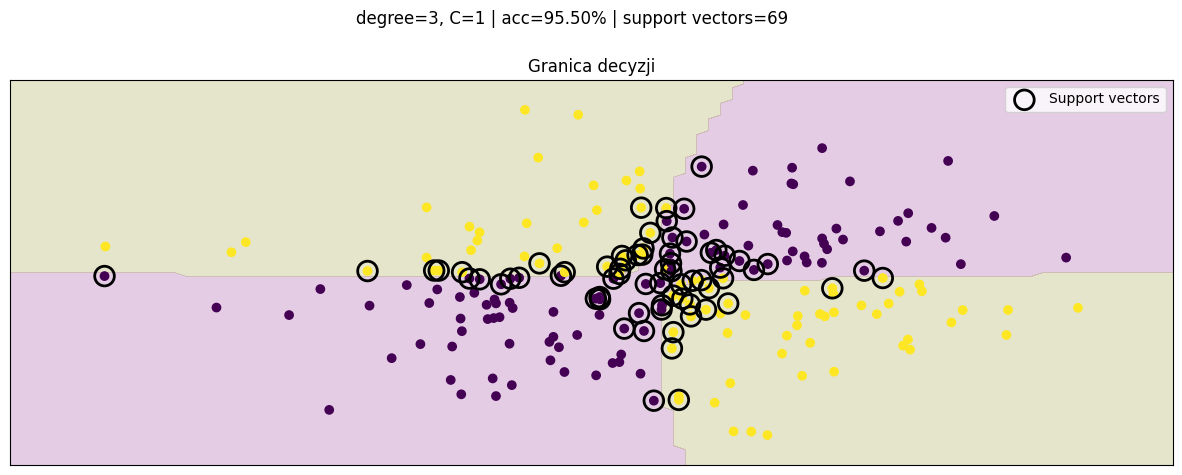

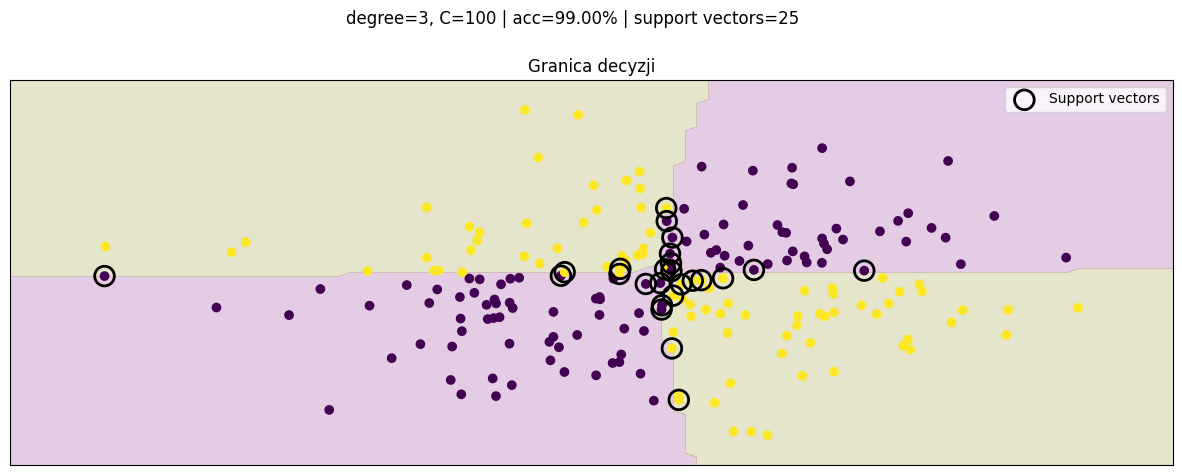

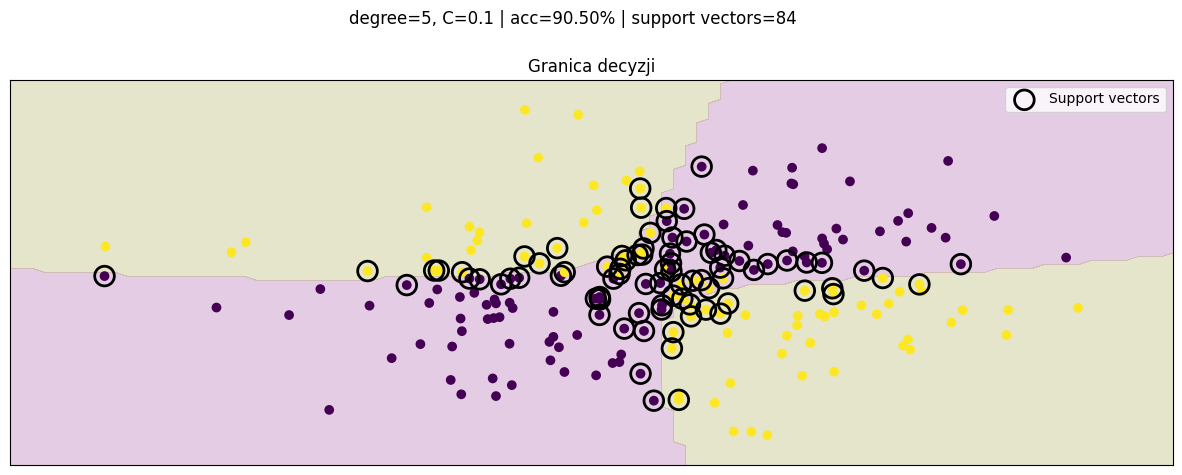

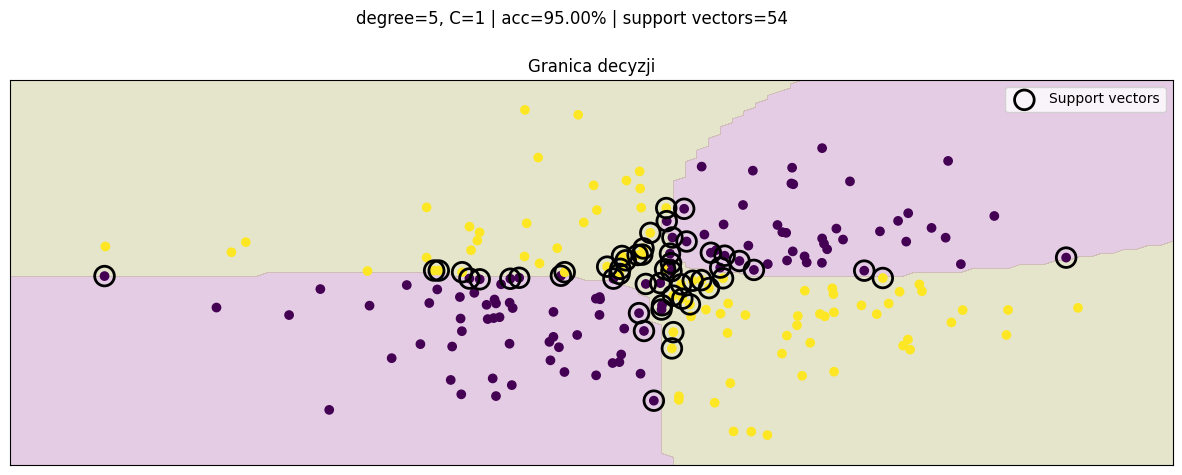

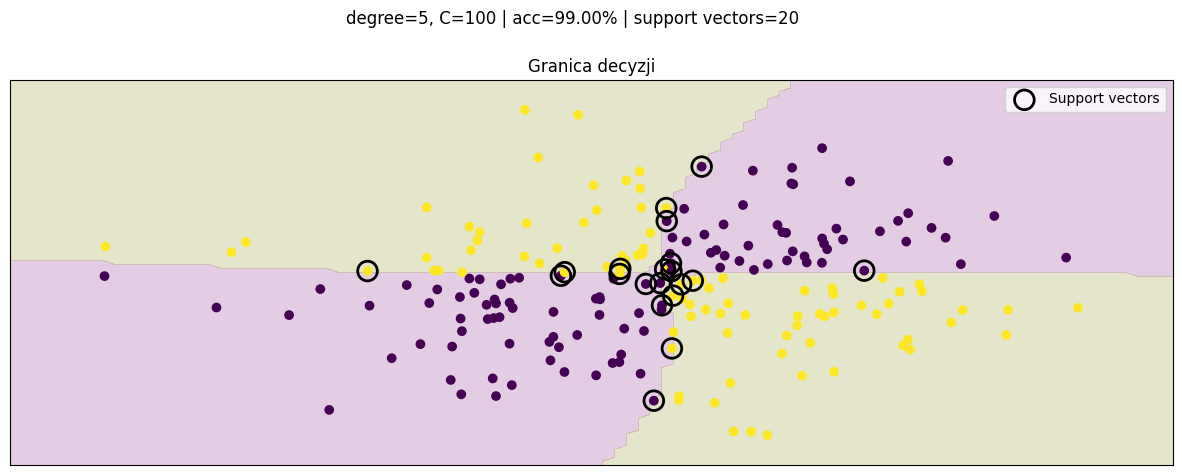

In [59]:
from sklearn.metrics import accuracy_score

for degree in [2, 3, 5]:
    for C in [0.1, 1, 100]:
        model = SVC(kernel='poly', coef0=1, degree=degree, C=C)
        model.fit(x, y)
        acc = accuracy_score(y, model.predict(x))
        n_sv = model.support_vectors_.shape[0]

        plot_classifier(x, y, model)

        plt.scatter(
            model.support_vectors_[:, 0],
            model.support_vectors_[:, 1],
            s=200, facecolors='none', edgecolors='black',
            linewidths=2, label='Support vectors'
        )
        plt.legend()
        plt.gcf().suptitle(
            f'degree={degree}, C={C} | acc={acc:.2%} | support vectors={n_sv}',
            y=1.02
        )
        plt.show()

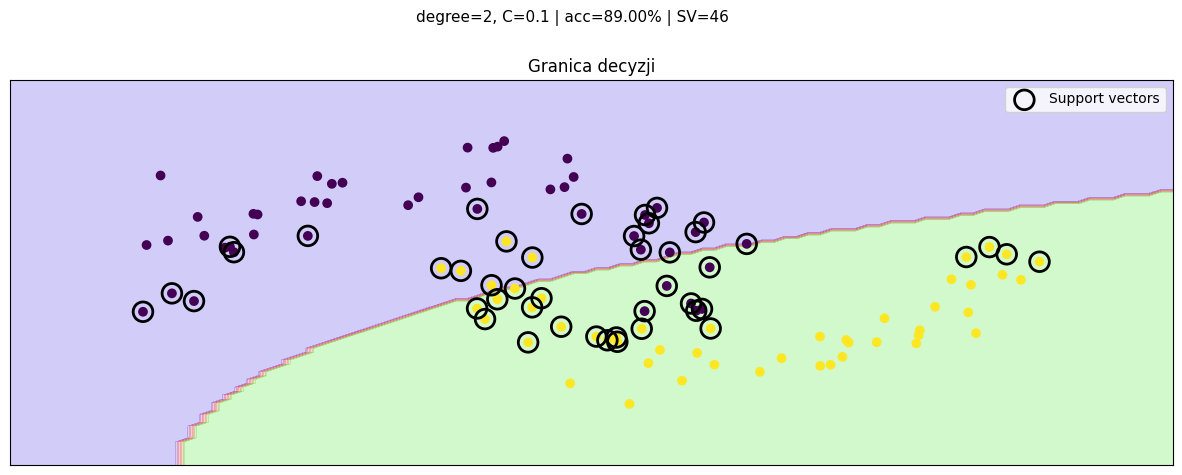

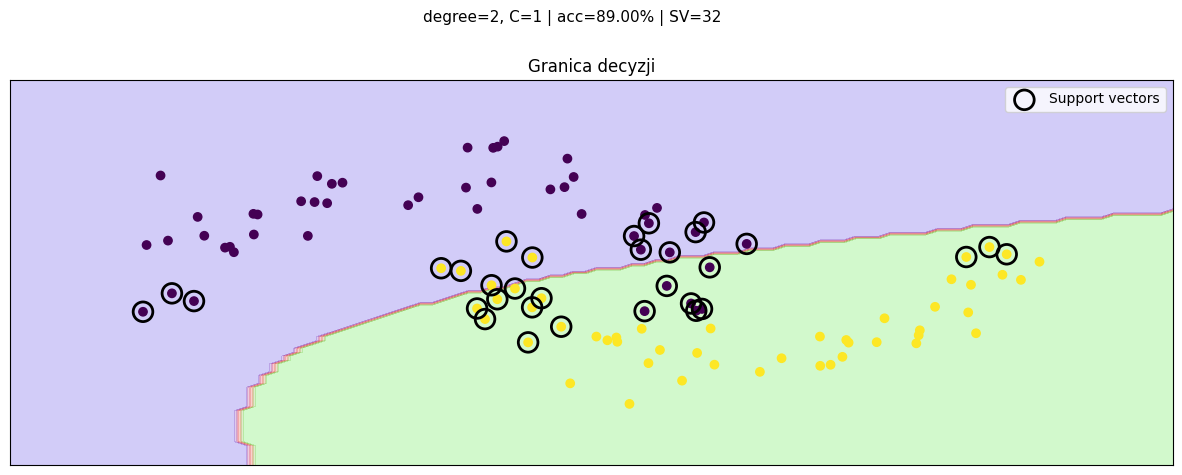

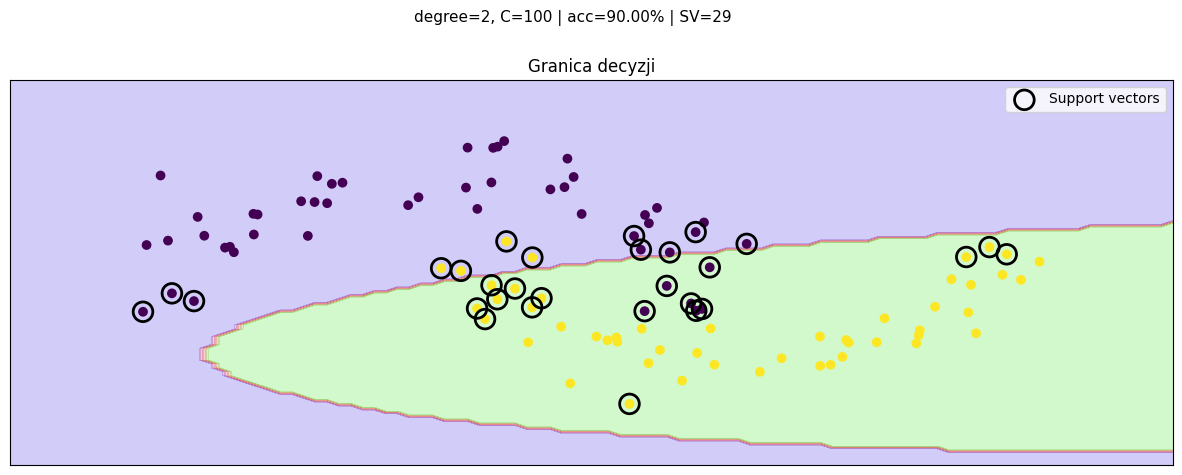

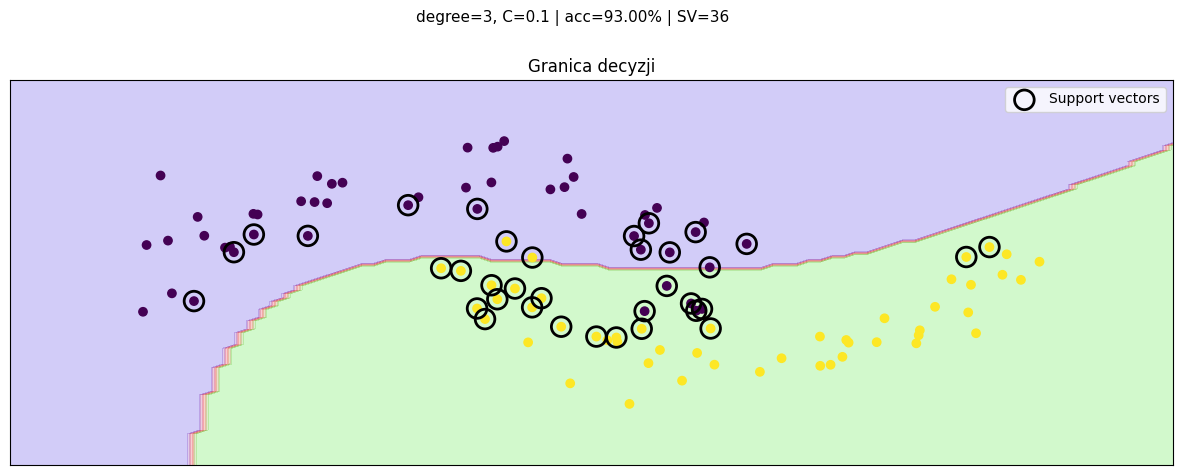

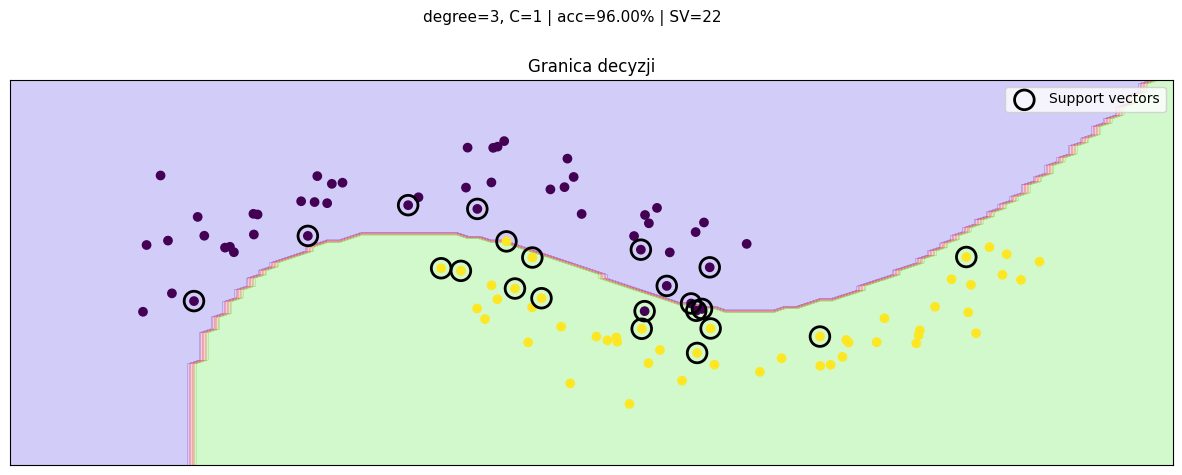

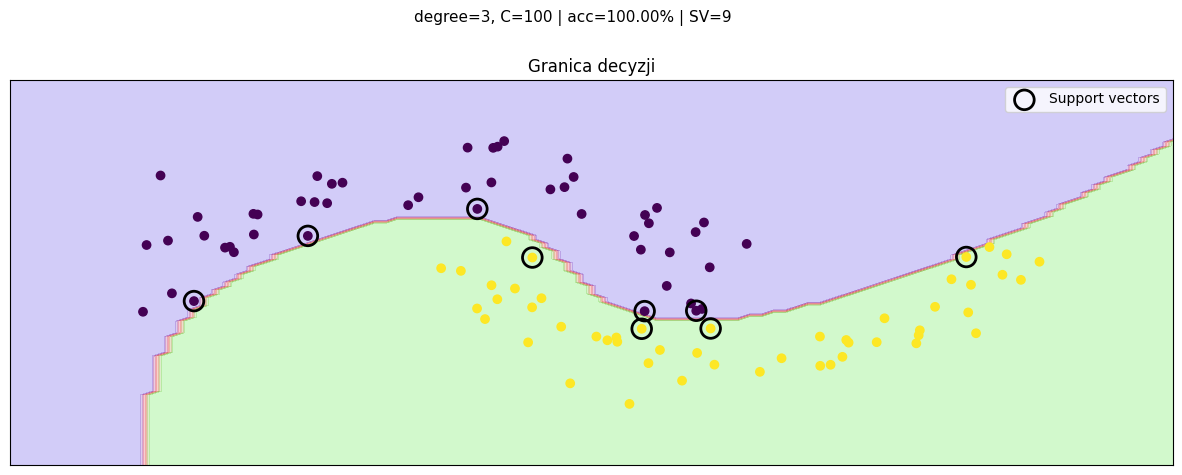

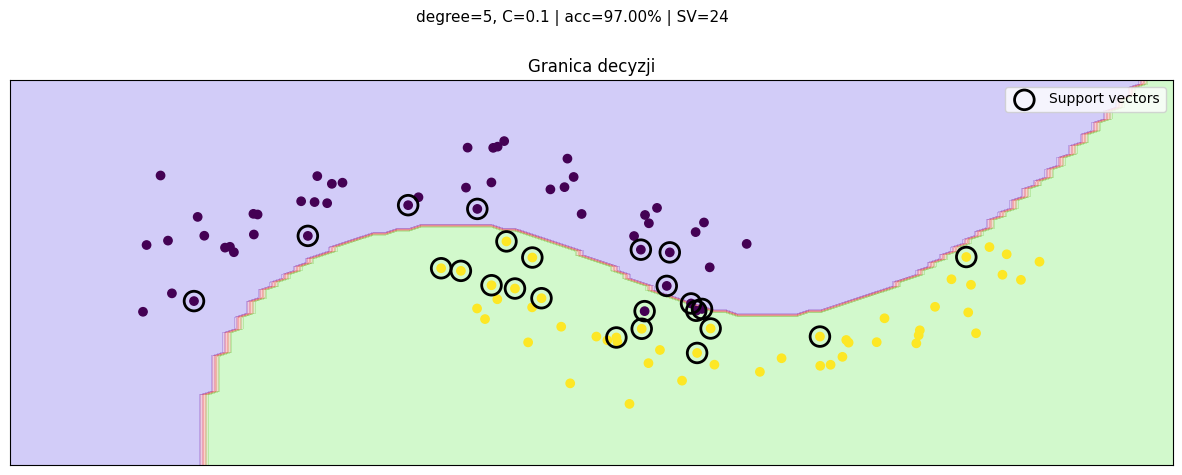

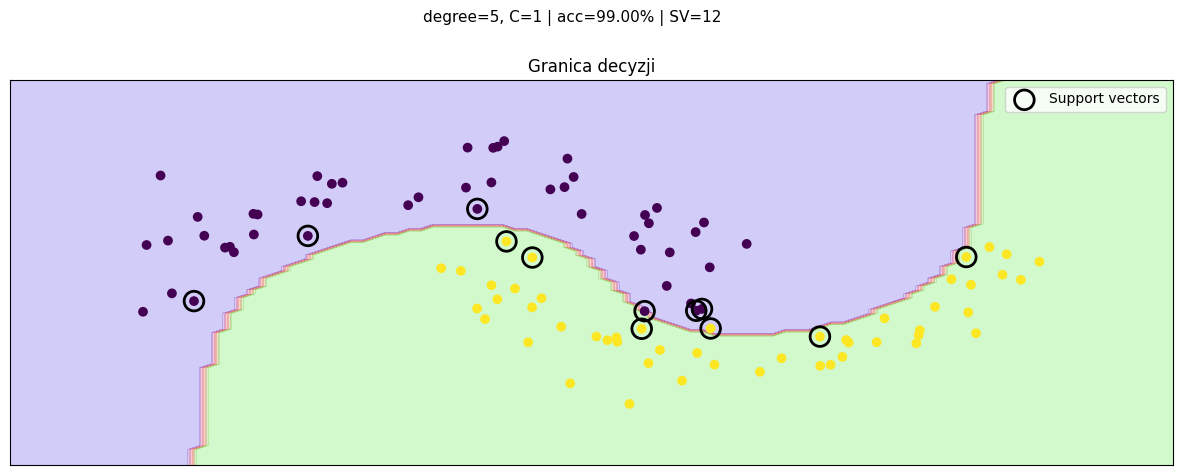

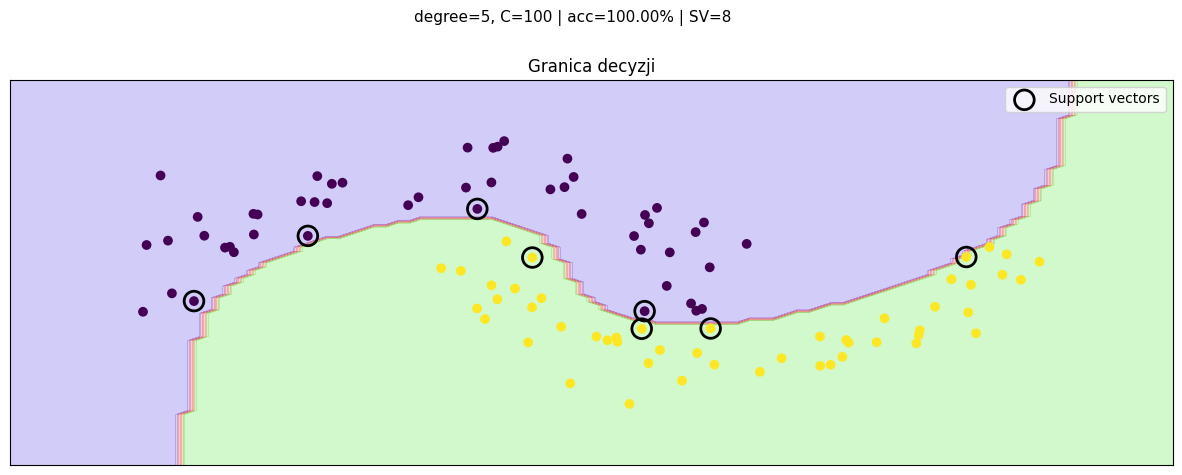

In [60]:
#Księżyce
x_moons, y_moons = make_moons(n_samples=100, noise=0.15, random_state=2024)
y_moons = np.where(y_moons == 0, -1, 1)

for degree in [2, 3, 5]:
    for C in [0.1, 1, 100]:
        model = SVC(kernel='poly', coef0=1, degree=degree, C=C)
        model.fit(x_moons, y_moons)
        acc = accuracy_score(y_moons, model.predict(x_moons))
        n_sv = model.support_vectors_.shape[0]

        plot_classifier(x_moons, y_moons, model)

        plt.scatter(
            model.support_vectors_[:, 0],
            model.support_vectors_[:, 1],
            s=200, facecolors='none', edgecolors='black',
            linewidths=2, label='Support vectors'
        )
        plt.legend()
        plt.gcf().suptitle(
            f'degree={degree}, C={C} | acc={acc:.2%} | SV={n_sv}',
            y=1.02, fontsize=11
        )
        plt.show()

Prawdopodobnie najczęściej stosowaną funkcją jądrową jest jądro RBF (*Radial basis function kernel*) wyrażone wzorem:
$${\displaystyle K(\mathbf {x} ,\mathbf {x'} )=\exp(-\gamma \|\mathbf {x} -\mathbf {x'} \|^{2})}$$
który inaczej zapisany ${\displaystyle K(\mathbf {x} ,\mathbf {x'} )=\exp \left(-{\frac {\|\mathbf {x} -\mathbf {x'} \|^{2}}{2\sigma ^{2}}}\right)}$ przypomina wzór na rozkład normalny (przy $\gamma^{-1} = 2\sigma ^{2}$). Jego działanie możemy sobie wyobrazić jako stosowanie rozkładu normalnego, który jest wycentrowany na rozważanym przykładzie $\mathbf{x}$ do mierzenia podobieństwa z innymi przykładami. Przypisuje on najwyższe "prawdopodobieństwo" (wartość funkcji jądrowej) do naszej obserwacji $\mathbf{x}$ a im dalej od niej tym wartość spada. Jeśli więc inny przykład $\mathbf{x'}$ leży blisko $\mathbf{x}$ w przestrzeni cech to jądro odpowie wysoką wartością, im dalej tym odpowiedź będzie niższa. Z kształtu rozkładu normalnego wiemy też, ze po przekroczeniu pewnej odległości ($3\sigma$) jądro będzie odpowiadało zawsze (prawie) zerem. Szybkość opadania funkcji jądra reguluje właśnie parametr $\sigma$: im jest on wyższy, tym wariancja (szerokość) rozkładu jest wyższa, więc jądro wolniej spada. Innymi słowy przykłady mają "większy zakres oddziałowywawania" na inne przykłady. W kontekście jądra RBF przyjęło się sterować parametrem $\gamma$, który jak już podawałem wynika z podstawienia:
$$\gamma = \frac{1}{2\sigma ^{2}}$$
czyli im wyższe $\gamma$ (niższe $\sigma$) tym mniejszy zakres oddziałowywania, funkcja szybciej spada z odległością od przykładu i na odwrót.

Niezwykłą ciekawostką dot. tej funkcji jądrowej jest to, że gdybyśmy zastanowili się jak wygląda przestrzeń cech które powinniśmy wygenerować aby dostać taki wynik bez użycia triku jądrowego to okazałoby się, że jest ich... nieskończenie wiele!

Jak pewnie się domyślasz, zastąpienie w konstruktorze `SVC` wyboru jądra na `kernel="rbf"` oraz podanie parametru `gamma` umożliwi ci przetestowanie SVM z jądrem RBF.

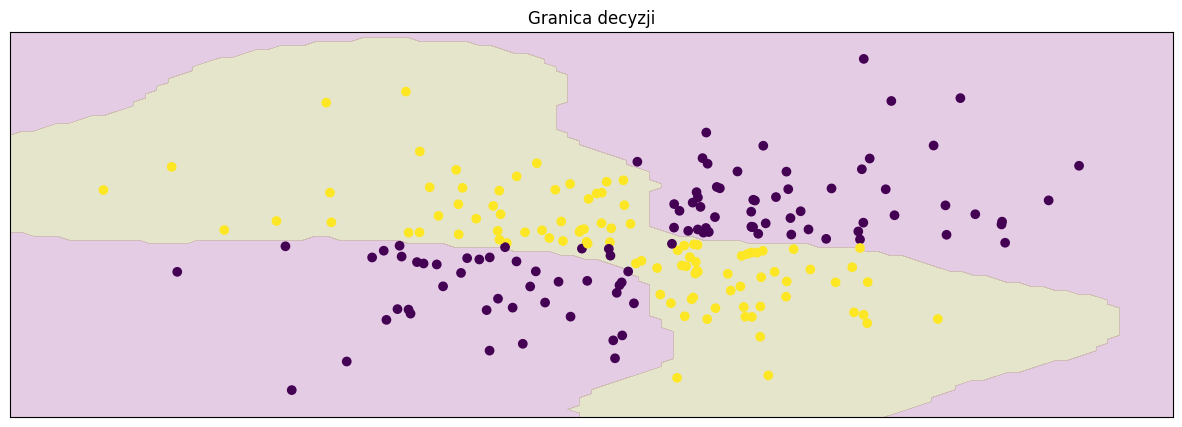

In [61]:
x = np.random.randn(200, 2)
y = np.logical_xor(x[:, 0] > 0, x[:, 1] > 0)


def plot_rbf(gamma: float) -> None:
    """Funkcja rysująca granicę decyzji klasyfikatora SVM z jądrem RBF.

    Args:
        gamma (float): Parametr gamma jądra RBF

    Returns:
        None

    """

    model = SVC(kernel='rbf', gamma=gamma)
    model.fit(x, y)
    plot_classifier(x, y, model)


plot_rbf(2)

**Polecenia**:
1. Przetesuj kilka wartości `gamma`. Rozważ przynajmniej wartości 0.01, 0.1, 1, 10.
2. Jakie wartości `gamma` powodują przeuczenie, a jakie niedouczenie?
3. Wczytaj poprzedni problem z dwoma księżycami i spróbuj dobrać `gamma`.
4. Wygeneruj zbiór z szachownicą
    ```
    x = np.random.rand(2000,2)*20
    y = np.sin(x[:,0])+np.sin(x[:,1])>0
    ```
    i spróbuj wybrać odpowiednio sparametryzowaną funkcję jądrową.

5. Czy klasyfikator SVM jest odporny na zmianę skali? Innymi słowy czy powinno się normalizować cechy przed jego użyciem? Dlaczego?
6. Jak myślisz czy dla każdego problemu (lub ew. prawie każdego) jest możliwe takie dobranie jądra np. wielomianowego aby zbiór był liniowo separowalny? Tj. byłoby w tej przestrzeni możliwe nauczenie klasyfikatora SVM z $C=\infty$? (Możesz spróbować, ale nie musisz)
7. Klasyfikator SVM jest binarny. Jak mógłbyś go użyć do klasyfikacji danych wieloklasowych?

Odpowiedź na punkty 2., 5. i 7. wpisz poniżej (krótkie konkretne odowiedzi wystarczą), dla reszty pozostaw kod w komórkach i ich wyniki jako dowód Twoich eksperymentów.

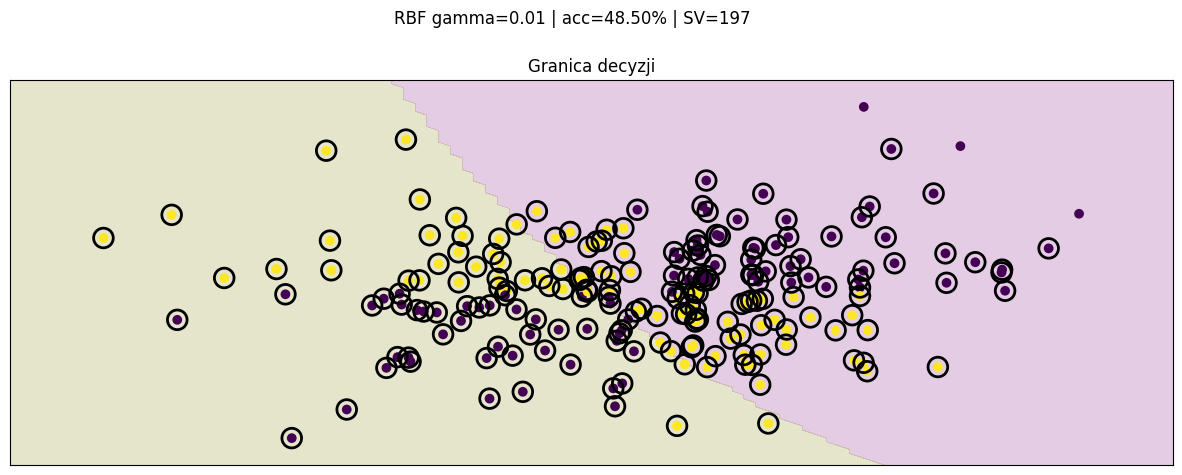

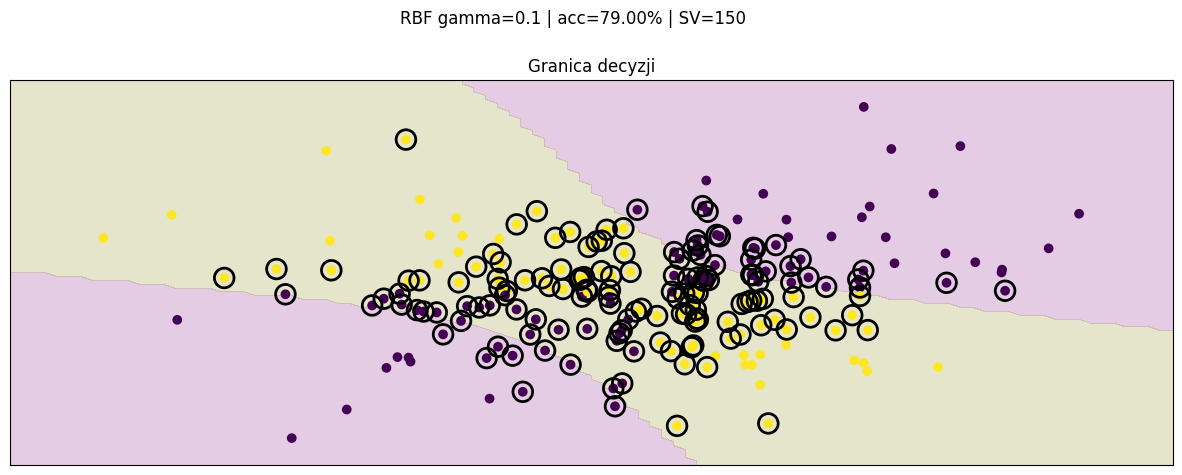

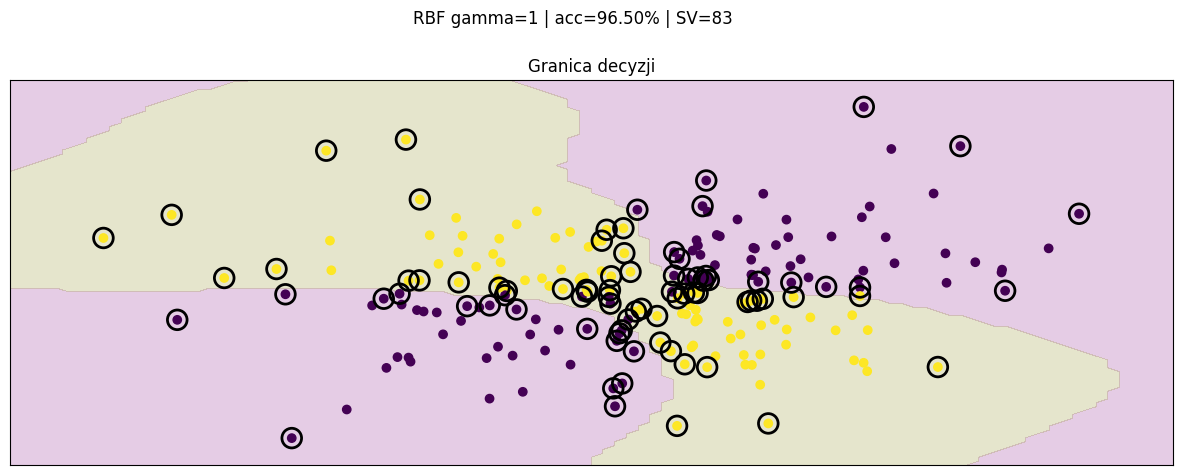

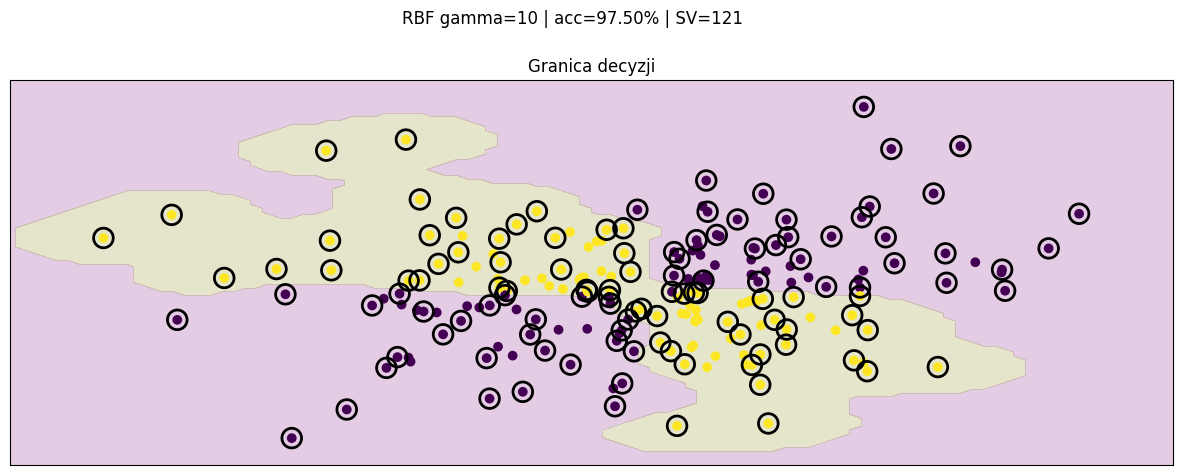

In [62]:
#XOR
for gamma in [0.01, 0.1, 1, 10]:
    model = SVC(kernel='rbf', gamma=gamma)
    model.fit(x, y)
    acc = accuracy_score(y, model.predict(x))
    n_sv = model.support_vectors_.shape[0]
    plot_classifier(x, y, model)
    plt.scatter(model.support_vectors_[:,0], model.support_vectors_[:,1],
                s=200, facecolors='none', edgecolors='black', linewidths=2)
    plt.gcf().suptitle(f'RBF gamma={gamma} | acc={acc:.2%} | SV={n_sv}', y=1.02)
    plt.show()

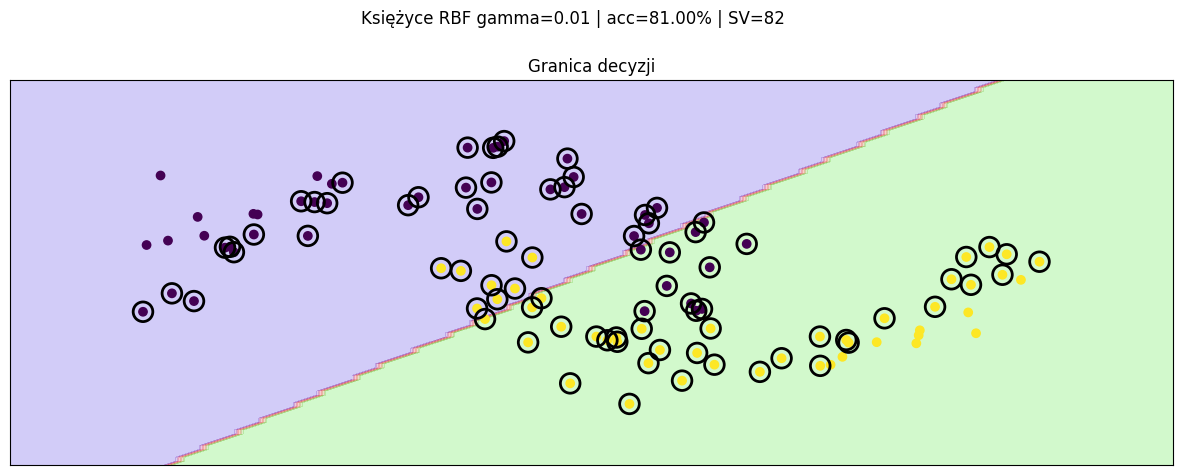

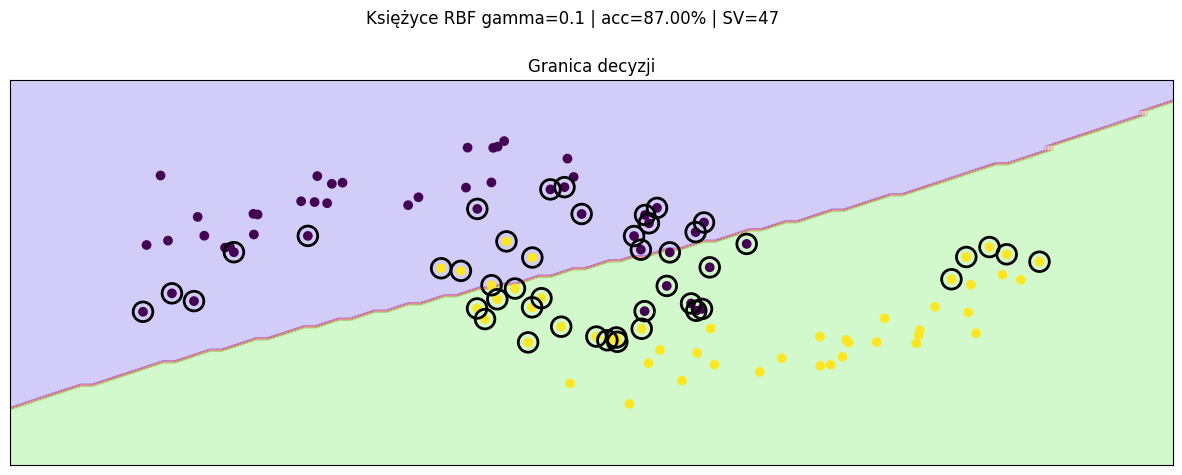

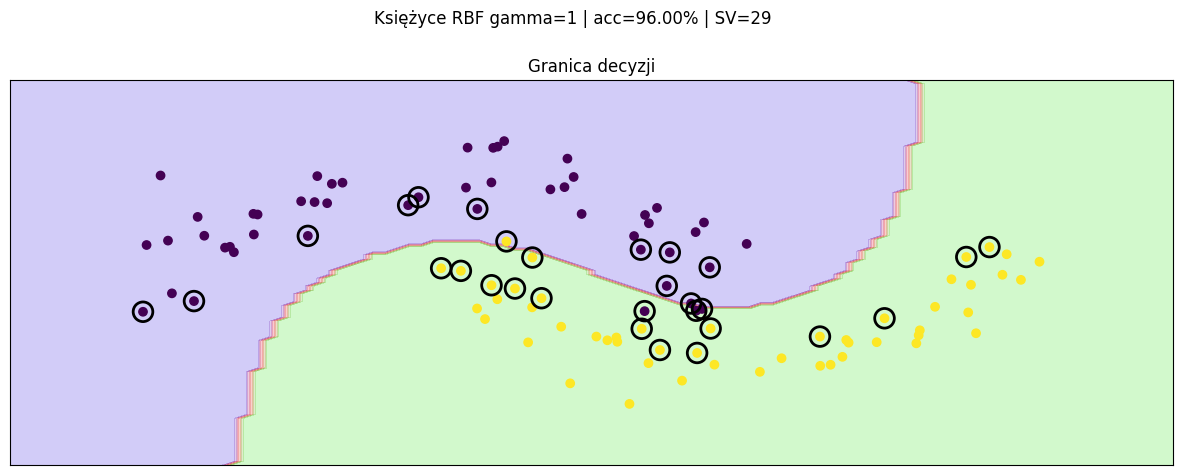

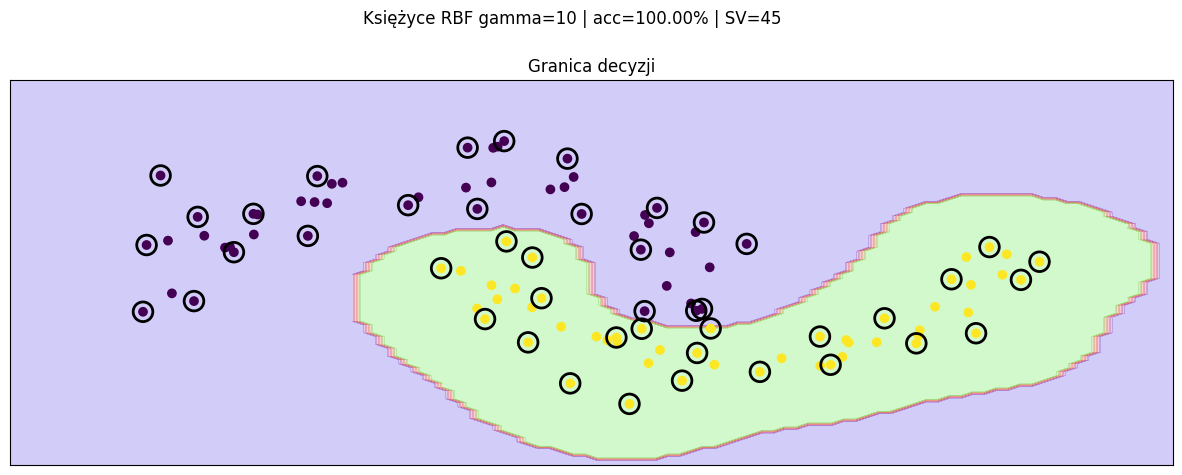

In [63]:
#Księżyce
x_moons, y_moons = make_moons(n_samples=100, noise=0.15, random_state=2024)
y_moons = np.where(y_moons == 0, -1, 1)

for gamma in [0.01, 0.1, 1, 10]:
    model = SVC(kernel='rbf', gamma=gamma)
    model.fit(x_moons, y_moons)
    acc = accuracy_score(y_moons, model.predict(x_moons))
    n_sv = model.support_vectors_.shape[0]
    plot_classifier(x_moons, y_moons, model)
    plt.scatter(model.support_vectors_[:,0], model.support_vectors_[:,1],
                s=200, facecolors='none', edgecolors='black', linewidths=2)
    plt.gcf().suptitle(f'Księżyce RBF gamma={gamma} | acc={acc:.2%} | SV={n_sv}', y=1.02)
    plt.show()

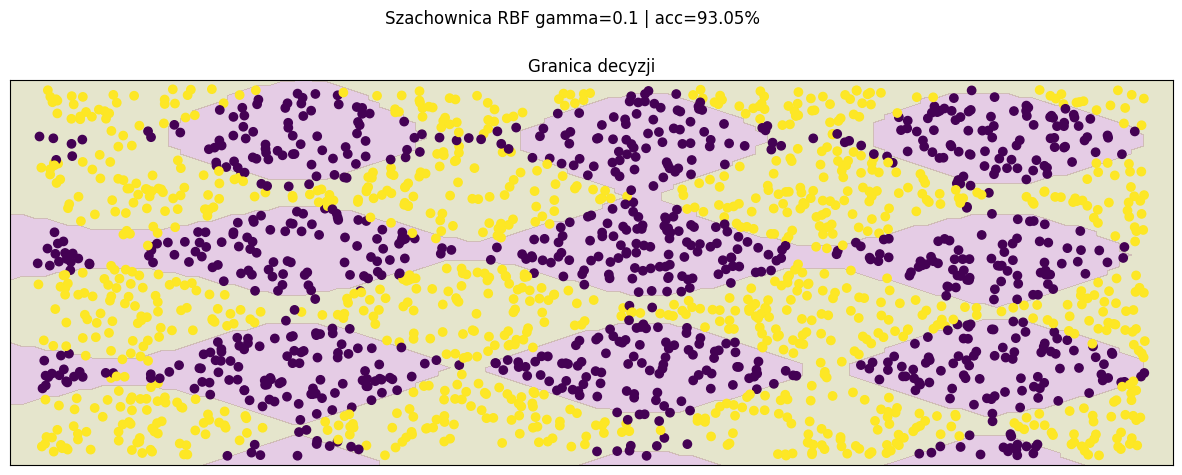

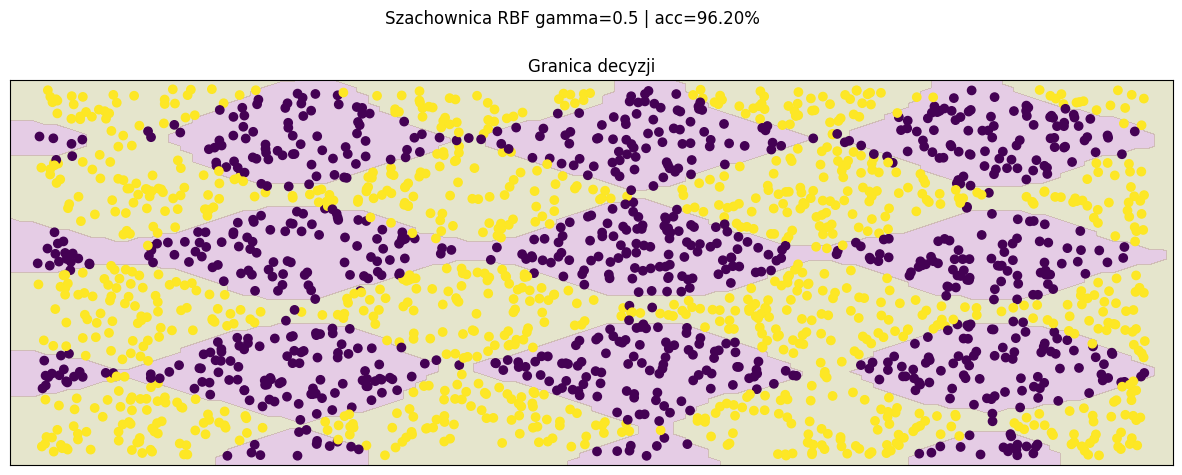

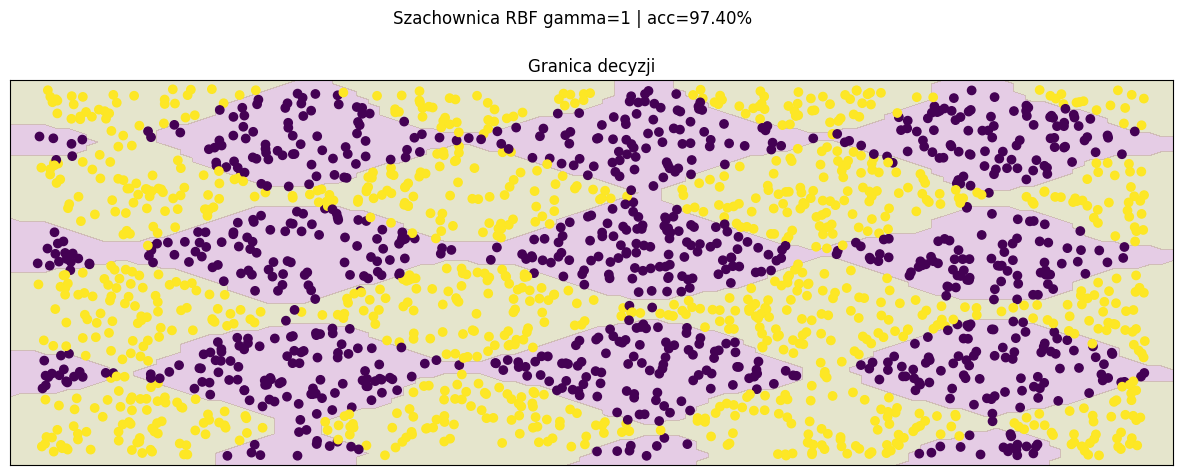

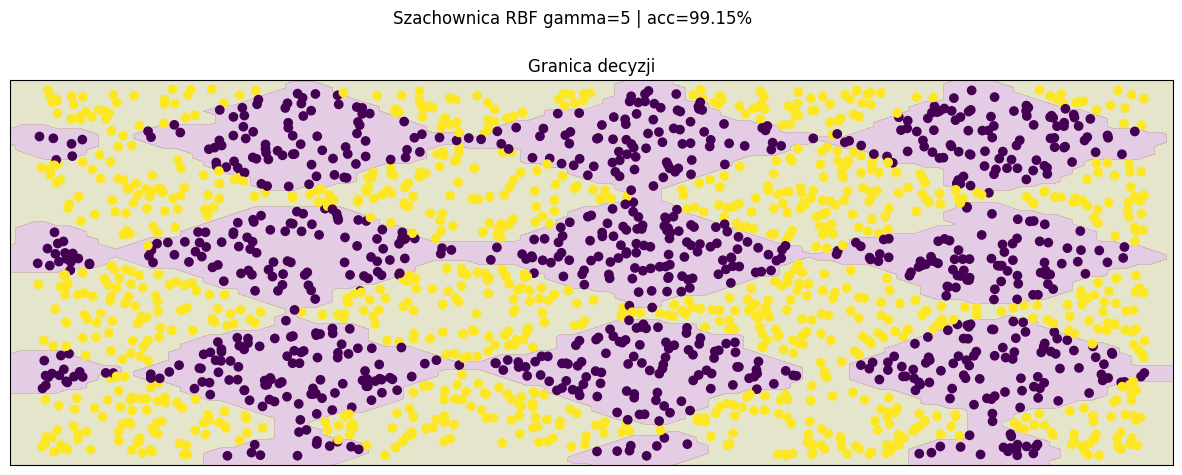

In [64]:
#Szachownica
x_chess = np.random.rand(2000, 2) * 20
y_chess = np.sin(x_chess[:,0]) + np.sin(x_chess[:,1]) > 0

for gamma in [0.1, 0.5, 1, 5]:
    model = SVC(kernel='rbf', gamma=gamma)
    model.fit(x_chess, y_chess)
    acc = accuracy_score(y_chess, model.predict(x_chess))
    plot_classifier(x_chess, y_chess, model)
    plt.gcf().suptitle(f'Szachownica RBF gamma={gamma} | acc={acc:.2%}', y=1.02)
    plt.show()

Odpowiedzi:

2: Im większa wartość gamma (np. 10), tym promień oddziaływania jednej próbki jest mniejszy, granica decyzji bliżej każdego punktu. Accuracy na zbiorze treningowym jest wtedy co prawda lepsze, ale model nie generalizuje - czyli overfitting. Z kolei dla bardzo małych wartości gamma (0.01, 0.1), bardzo mocny underfitting, bo każda próbka oddziałuje na bardzo duży obszar. Dla XOR jest granica decyzji jest prawie liniowa, czyli zachowuje się jak liniowy SVM. Dla danych "księżycowych" 0.01 granica również jest prawie liniowa. Przy 0.1 jest nieco lepiej, bo pojawiła się już jakaś krzywizna, która choć trochę dopasowuje się do kształtu danych, jednak nadal duża liczba wektorów wspierających, czyli margines nie jest dobrze wyznaczony.

5: Nie jest odporny, ponieważ jądro RBF opiera się na odległości Euklidesowej między punktami. W przypadku, gdy pracujemy na cechach, które mają inne skale, np. jedna liczona w dziesiątkach, druga w tysiącach, to ta pierwsza zostanie zdominowana przez drugą przy obliczaniu odległości, model nie będzie wrażliwy na cechy o mniejszach zakresach wartości. Przed użyciem SVM należy normalizować/standaryzować cechy.

7: Aby umożliwić klasyfikację wieloklasową za pomocą klasyfikatora SVM, należy rozłożyć zadanie na kilka klasyfikatorów binarnych. Możemy np. wytrenować klasyfikatory dla każdej z klas - klasyfikator będzie odróżniać daną klasę od pozostałych (1 - ta klasa, 0 - pozostałe klasy). Dla n klas potrzeba zatem n klasyfikatorów.

W innym podejściu można wytrenować klasyfikatory dla wszystkich par klas (kombinacja bez powtórzeń n po 2, czyli n(n-1)/2 klasyfikatorów). Ostateczna decyzja jest podejmowana na podstawie głosowania - przepuszczamy próbkę przez wszystkie klasyfikatory, a każdy z nich wybiera jedną z dwóch klas.

## Zadanie 4. - Wybór parametrów (za 20%)

Wygeneruj dane z szachownicą (takie same jak w zadanich wyżej)

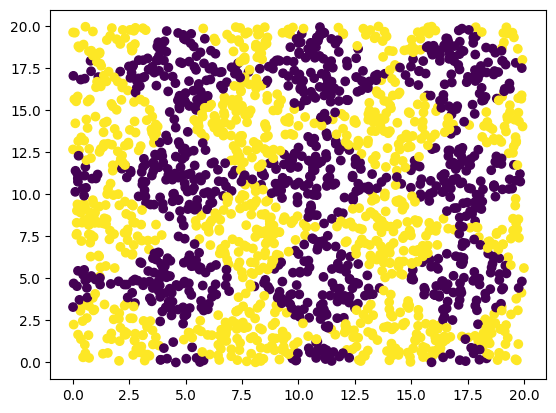

In [65]:
x = np.random.rand(2000, 2) * 20
y = np.sin(x[:, 0]) + np.sin(x[:, 1]) > 0
plt.scatter(x[:, 0], x[:, 1], c=y)

Spróbuj wybrać optymalne parametry dla klasyfikatora SVM z jądrem RBF (weź pod uwagę parametr `gamma` jądra i parametr `C`). Przykładową techniką poszukiwania dobrych parametrów jest zdefiniowanie tzw. siatki parametrów i sprawdzenie wszystkich możliwości. W pierwszym kroku musimy ustalić siatkę czyli np. dla parametru `gamma` będziemy testować wartości 0.1, 1, 10, a dla parametru `C` wartości 1 i 10. Poszukiwanie gridowe dla takiej siatki uruchomi proces uczenia 6 razy, zewaluuje trafność i zwróci najlepsze parametry. Ewaluacja trafności może się odbywać np. walidacją krzyżową, a w `sklearn` jest to zaimpementowane w obiekcie `GridSearchCV`.

Pierwszym argumentem konstruktora obiektu `GridSearchCV` jest obiekt klasyfikatora, a kolejne ważne parametry to ` param_grid= słownik z siatką`, `scoring='accuracy'` (aby była ewaluowana trafność). Dodatkowo można ustawić `verbose=2` jeśli chcesz, żeby pojawiły się na konsoli dodatkowe informacji o uczeniu kolejnych klasyfikatorów oraz parametrem `cv=` kontrulującym na ile cześci powinien zostać podzielony zbiór uczący w trakcie walidacji krzyżowej. Np.
```
GridSearchCV(KLASYFIKATOR, param_grid= PARAMETRY scoring='accuracy', verbose=2, cv=3)
```
Siatkę `PARAMETRY` definiujemy poprzez podanie słownika, którego kluczami są nazwy parametrów klasyfikatora, a wartościami są listy wartości do sprawdzenia np. `{'gamma':[0.1,1,10], 'C':[1,10]}`. `GridSearchCV` uruchamiamy standardowo czyli porzez funkcję `fit()`.

Znajdź dobre ustawienia klasyfikatora SVM z jądrem RBF dla problemu z szachownicą.

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Najlepsze parametry: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Najlepsza trafność CV: 0.9370


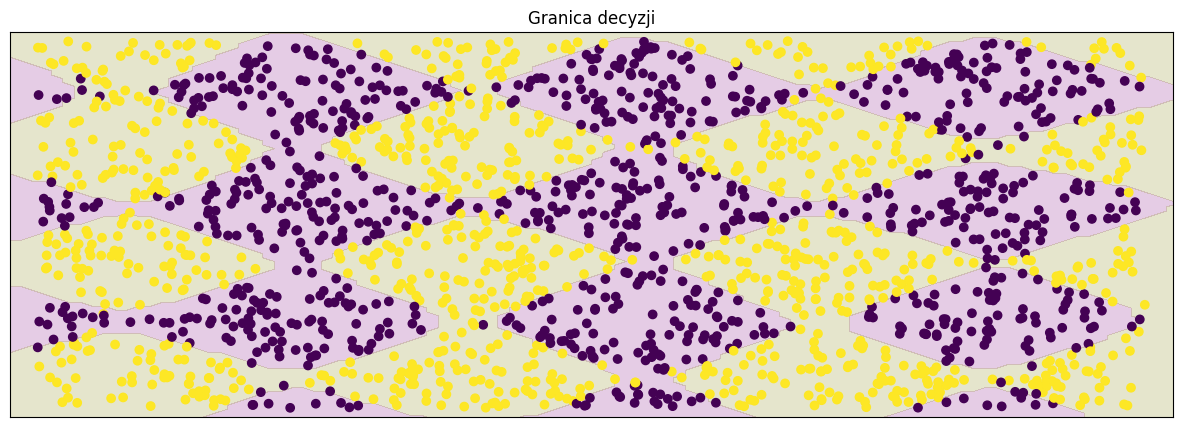

In [70]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

params = [
    {
        'kernel': ['linear'],
        'C': [0.1, 1, 10]
    },
    {
        'kernel': ['poly'],
        'C': [0.1, 1, 10],
        'degree': [2, 3, 5],
        'coef0': [0, 1]
    },
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10],
        'gamma': [0.1, 1, 10]
    }
]

grid = GridSearchCV(SVC(), param_grid=params, scoring='accuracy', cv=3, n_jobs=4, verbose=2)
grid.fit(x, y)

print(f"Najlepsze parametry: {grid.best_params_}")
print(f"Najlepsza trafność CV: {grid.best_score_:.4f}")

model = SVC(**grid.best_params_)
model.fit(x, y)
plot_classifier(x, y, model)

Przyjrzyj się wynikowi - właściwość `GRID.best_params_`

In [71]:
grid.best_params_

{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}

Oraz szczegółom przeszukiwania - właściwość `GRID.cv_results_`

In [72]:
grid.cv_results_

{'mean_fit_time': array([8.78059546e-01, 1.73931154e+00, 3.78619631e+00, 3.27415546e-01,
        3.91095082e-01, 3.49031981e+00, 2.40597804e-01, 3.42172225e-01,
        2.57959119e+00, 3.05292765e-01, 1.22702448e+00, 2.09828978e+01,
        4.78856802e-01, 9.40546195e-01, 1.60254625e+01, 7.84687519e-01,
        7.11354121e+00, 1.49543553e+02, 6.39399211e-01, 5.14550042e+00,
        1.04083536e+02, 2.10327387e-01, 2.32399543e-01, 3.49631945e-01,
        2.36632347e-01, 2.82777627e-01, 4.47356065e-01, 1.09747012e-01,
        1.21081511e-01, 3.90597026e-01]),
 'std_fit_time': array([1.12168901e-01, 6.85841093e-02, 2.36285744e-01, 3.41255990e-02,
        7.39823048e-02, 5.74976763e-01, 7.65099311e-02, 3.37777435e-02,
        2.61773606e-01, 2.90275497e-02, 1.06826097e-01, 4.98159988e+00,
        3.07250982e-02, 1.24012038e-01, 3.18528516e+00, 1.49656284e-02,
        1.49482844e+00, 3.52342730e+01, 6.84844502e-02, 7.12267888e-01,
        1.56168632e+01, 2.60872525e-02, 2.32229406e-03, 2.674

Wytrenuj klasyfikator z najlepszymi znalezionymi parametrami i zwizualizuj go `plot_classifier`.

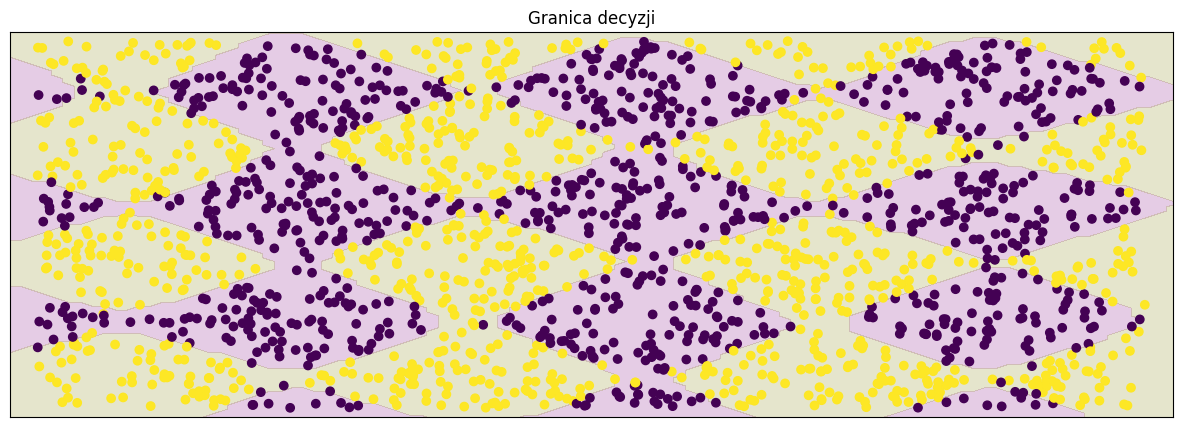

In [75]:
model = SVC(**grid.best_params_)
model.fit(x, y)
plot_classifier(x, y, model)

**Polecenia**
1. Typ funkcji jądrowej może być jednym z parametrów które stroimy. Jednak różne funkcje jądrowe mają różne parametry - jak to wyspecyfikować? Zobacz fragment [dokumentacji sekcja 3.2.1 ](https://scikit-learn.org/stable/modules/grid_search.html#exhaustive-grid-search), który pokazuje jak to zrobić. Rozszerz twoje przeszukiwanie o jądra liniowe i wielomianowe.
2. Spróbuj strojenia na innym wybranym zbiorze.
3. Czy wynik uzyskany przez GridSearchCV jest dobrą estymacją trafności na zbiorze testowym?

Odpowiedź na punkt 3. poniżej.

3. Ponieważ w GridSearchCV stosuje się walidację krzyżową, jest ona co prawda lepszą estymacją niż pojedynczy podział na zbiór treningowy i testowy - uśrednia wyniki. Sam wybór danych do poszczególnych foldów jest jednak ulosowiony, przez co wybór najlepszych parametrów to wybór konfiguracji, która wypadła najlepiej częściowo przez przypadek. Im więcej parametrów rozważamy, tym to ryzyko jest większe. Estymacja trafności z GridSearchCV nie jest zatem obiektywną estymacją na zbiorze testowym. Aby uzyskać dobrą estymację, ostateczny model z wybranymi parametrami trzeba sprawdzić na całkowicie odseparowanym zbiorze testowym.

## Zadanie 5. - SVM dla dużych danych (za 20%)

In [76]:
from helpers import get_wine

x, y = get_wine()

Metoda maszyn wektorów podpierających ma wiele zalet. Po pierwsze tworzy modele z dość małą liczbą wektorów podpierających które determinują wielkość nauczonego modelu. Dodatkowo faza predykcji jest bardzo szybka. Ponieważ uczenie jest zależne tylko od kilku, automatycznie wybieranych, wektorów podpierających, a resztę zbioru danych można by usunąć bez zmiany wyindukowanego klasyfikatora to wynik SVM zwykle zależy od małego podzbioru zbioru uczącego. SVM dobrze sobie radzą nawet w sytuacji gdy liczba przykładów jest dalece mniejsza niż liczba cech! (Przypomnij sobie co się wtedy dzieje z regresją liniową). Dodatkowo, pomimo tego że SVM jest klasyfikatorem liniowym to zastosowanie triku jądrowego pozwala na indukcje płaszczyzny separującej w rozszerzonej przestrzeni. Ponadto trik jądrowy pozwala na tworzenie własnych jąder dostosowanych do dziedziny problemu (tak jak w kNN mogliśmy projektować funkcje odległości) co spowodowało  szerokie ich wykorzystanie w tekstach czy obrazach (istnieją gotowe funkcje jądrowe nawet do przetwarzania grafów).

Jeśli chodzi o najważniejsze wady tego klasyfikatora to pierwszą dużą wadą jest konieczność strojenia parametrów funkcji jądrowych oraz parametru $C$. Jednakże w świetle powszechnego korzystania z sieci neuronowych, które wymagają strojenia znacznie większej liczby parametrów (architektura, różne dodatkowe triki) nie wiem czy nadal powinno się to uważać za  wadę nie do przeskoczenia. Druga wada SVM jest jednak znaczenie gorsza: koszt obliczeniowy uczenia. Rozwiązywanie problemu programowania kwadratowego definiowanego przez SVM jest rzędu sześciennego od liczby przykładów $\mathcal{O}[n^3]$ czy dla efektywniejszych implementacji $\mathcal{O}(\max(n,d) \min (n,d)^2)$  - nadal jest to bardzo kosztowne obliczeniowo.

Jednakże na ten drugi problem możemy rozwiązać za pomocą algorytmów w rodzaju stochastycznego spadku wzdłuż gradientu! Funkcja celu która jest optymalizowana przez SVM nazywamy funkcją zwiasową (*hinge loss*) i jest ona ekwiwalentna z prymalną postacią problemu. Jednak to właśnie jego postać dualna umożliwiała zastosowanie triku jądrowego. Aby więc zastosować SGD trzeba by rzeczywiście przeskalować zbiór uczący do przestrzeni cech definiowanej przez jądro (ona może mieć nawet $\infty$ liczbę wymiarów!). Na szczęście tak jak SGD używa przybliżonej estymacji gradientu tak samo możemy użyć *przybliżonej* transformacji jądrowej. Jedną z takich technik jest aproksymacja Nyströma, która wychodzi z założenia że macierz jądrowa jest rzędu $m$ dalece mniejszego od $n$. Zakłada się więc, że mając tylko wiedzę o $m$ wierszach macierzy jądrowej można zrekonstruować ją całą. W praktyce nie jest to prawda, ale po prostu mamy nadzieję, że $n-m$ najmniejszych wartości własnych jest na tyle małe że i tak uzyskujemy dobrą aproksymację (patrz: Materiały dla chętnych).

Wytrenuj na wczytanych danych SVM poprzez algorytm SGD - obiekt `SGDClassifier`. Pamiętaj o wyspecyfikowaniu zawiasowej funkcji straty `loss='hinge'`. Dodatkowo, aby wykonać trik jądrowy przetransformuj dane wejściowe aprokymacją Nyströma (obiekt `Nystroem`). Parametry tego obiektu to `kernel` (ustawmy RBF) oraz `gamma` (dla RBF), a także ` n_components` czyli ile wektorów używanych jest do przybliżenia jądra (domyślnie 100 i do naszych celów jest to wystarczające).

In [77]:
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split

x_tr, x_te, y_tr, y_te = train_test_split(x, y, test_size=0.2)
nyst = Nystroem(kernel='rbf', n_components=100)
x_tr_nyst = nyst.fit_transform(x_tr)
x_te_nyst = nyst.fit_transform(x_te)

Porównaj czas uczenia na tych samych danych modelu `SVC` oraz modelu przybliżonego (`Nystroem`+`SGD`). Czas wykonania komórki kodu możesz przetestować poprzez dodanie do niej na początku znacznika
`%%timeit`.

In [78]:
%%timeit
model = SVC(kernel='rbf')
model.fit(x_tr, y_tr)

427 ms ± 103 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [79]:
%%timeit
model = SGDClassifier(loss='hinge')
model.fit(x_tr_nyst, y_tr)

38.8 ms ± 1.26 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


**Polecenia**
1. Zwiększ rozmiar zbioru pięciokrotnie (kopiując przykłady). Jak teraz wygląda czas uczenia klasyfikatora  obiema metodami?
2. Porównaj trafności obydwu metod na zbiorze uczącym i testowym.
3. Spróbuj przeskalować dane uczące przed użyciem obydwu metod np. metodą Min-Max
   ```
   from sklearn.preprocessing import MinMaxScaler
   scaler = MinMaxScaler()
   ```
   Jak zmienił się czas uczenia? Jak zmieniła się trafność modelu?

4. Przetestuj różne wartości `n_components` transformacji przybliżonej. Spróbuj zaobserwować zależności pomiędzy trafnością modelu a modelem referencyjnym (bez przybliżenia). Możesz też spróbować porównać czasy uczenia dla kliku wielkości `n_components`.

Zostaw kod w komórkach i ich wyniki na dowód Twoich eksperymentów.

In [87]:
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
import time

x_tr, x_te, y_tr, y_te = train_test_split(x, y, test_size=0.2)

x_tr_big = np.tile(x_tr, (5, 1))
y_tr_big = np.tile(y_tr, 5)

scaler = MinMaxScaler()
x_tr_scaled = scaler.fit_transform(x_tr_big)
x_te_scaled = scaler.transform(x_te)

print("Czas uczenia oryginał vs 5x większy zbiór:")
for label, X_train, y_train in [
    ('oryginalny', x_tr, y_tr),
    ('5x większy', x_tr_big, y_tr_big)
]:
    nyst = Nystroem(kernel='rbf', gamma=0.1, n_components=100)
    X_train_nyst = nyst.fit_transform(X_train)

    t0 = time.time()
    SVC(kernel='rbf').fit(X_train, y_train)
    print(f"SVC {label}: {time.time()-t0:.3f}s")

    t0 = time.time()
    SGDClassifier(loss='hinge').fit(X_train_nyst, y_train)
    print(f"SGD {label}: {time.time()-t0:.3f}s")

print("\nTrafności i wpływ skalowania:")
for label, X_train, X_test in [
    ('oryginalne', x_tr_big, x_te),
    ('skalowane',  x_tr_scaled, x_te_scaled)
]:
    print(f"\nDane: {label}")
    nyst = Nystroem(kernel='rbf', gamma=0.1, n_components=100)
    X_train_nyst = nyst.fit_transform(X_train)
    X_test_nyst  = nyst.transform(X_test)

    t0 = time.time()
    svc = SVC(kernel='rbf')
    svc.fit(X_train, y_tr_big)
    print(f"SVC czas: {time.time()-t0:.3f}s")
    print(f"SVC acc train: {accuracy_score(y_tr_big, svc.predict(X_train)):.4f}")
    print(f"SVC acc test:  {accuracy_score(y_te, svc.predict(X_test)):.4f}")

    t0 = time.time()
    sgd = SGDClassifier(loss='hinge')
    sgd.fit(X_train_nyst, y_tr_big)
    print(f"SGD czas: {time.time()-t0:.3f}s")
    print(f"SGD acc train: {accuracy_score(y_tr_big, sgd.predict(X_train_nyst)):.4f}")
    print(f"SGD acc test:  {accuracy_score(y_te, sgd.predict(X_test_nyst)):.4f}")


print("\nWpływ n_components: ")
for n in [1, 3, 5, 10, 50, 100, 200, 500]:
    nyst = Nystroem(kernel='rbf', gamma=0.1, n_components=n)
    X_train_nyst = nyst.fit_transform(x_tr_scaled)
    X_test_nyst  = nyst.transform(x_te_scaled)

    t0 = time.time()
    sgd = SGDClassifier(loss='hinge')
    sgd.fit(X_train_nyst, y_tr_big)
    t = time.time() - t0

    acc_tr = accuracy_score(y_tr_big, sgd.predict(X_train_nyst))
    acc_te = accuracy_score(y_te, sgd.predict(X_test_nyst))
    print(f"n={n:4d} | czas={t:.3f}s | acc_train={acc_tr:.4f} | acc_test={acc_te:.4f}")

Czas uczenia oryginał vs 5x większy zbiór:
SVC oryginalny: 0.588s
SGD oryginalny: 0.231s
SVC 5x większy: 16.546s
SGD 5x większy: 0.270s

Trafności i wpływ skalowania:

Dane: oryginalne
SVC czas: 8.094s
SVC acc train: 0.9417
SVC acc test:  0.9392
SGD czas: 0.182s
SGD acc train: 0.8493
SGD acc test:  0.8262

Dane: skalowane
SVC czas: 0.951s
SVC acc train: 0.9969
SVC acc test:  0.9962
SGD czas: 0.112s
SGD acc train: 0.9933
SGD acc test:  0.9923

Wpływ n_components: 
n=   1 | czas=0.049s | acc_train=0.7614 | acc_test=0.7362
n=   3 | czas=0.072s | acc_train=0.7916 | acc_test=0.7677
n=   5 | czas=0.049s | acc_train=0.9277 | acc_test=0.9408
n=  10 | czas=0.039s | acc_train=0.9931 | acc_test=0.9923
n=  50 | czas=0.100s | acc_train=0.9910 | acc_test=0.9923
n= 100 | czas=0.126s | acc_train=0.9935 | acc_test=0.9923
n= 200 | czas=0.221s | acc_train=0.9931 | acc_test=0.9923
n= 500 | czas=0.275s | acc_train=0.9933 | acc_test=0.9923


Odpowiedzi:

1. SVC skaluje się znacznie gorzej - teoretyczna złożoność O(n^3) sugerowałaby
wzrost ok. 125 razy, w praktyce wyszło nam ok. 28 razy (zapewne kwestia optymalizacji solvera). SGD w teorii skaluje się
prawie liniowo (tutaj wyszło 1,2 raza dla 5 razy większych danych), co potwierdza przewagę SGD na większych zbiorach danych.

2. SVC osiąga wyraźnie wyższe accuracy. SGD jest gorszy o ok. 10pp. - aproksymacja Nystroma i brak skalowania razem obniżają accuracy. SGD jest wrażliwy na skalę cech, więc cechy, które mają większe wartości, mogą zaburzać kierunek optymalizacji. Aproksymacja Nystroma nie odtwarza idealnie jądra RBF, bo stąd obecność błędu przybliżenia. Różnica między accuracy treningowym a testowym jest jednak znikoma, więc generalizacja na dobrym poziomie, nie zachodzi overfitting.

3. Skalowanie poprawiło działanie obu metod, ale najefektywniej poprawa wypada w przypadku SGD. Wzrost accuracy o ok. 14pp. - to nieskalowane cechy były główną przyczyną słabszych wyników. Po skalowaniu gradient jest obliczany w przestrzeni, gdzie wszystkie cechy mają równy wpływ. SVC przyspieszył po skalowaniu aż 7-krotnie, ponieważ jądro RBF opiera się na odległości euklidesowej, a gdy cechy mają różne zakresy, to zniekształca się odległości, przez co solver potrzebuje więcej iteracji na znalezienie rozwiązania.

4. Przełom między n=5 a n=10. Powyżej n=10 accuracy stabilizuje się, kolejne zwiększanie c_components nie przynosi żadnej poprawy przy rosnącym czasie uczenia. Oznacza to, że już 10 losowo wybranych punktów referencyjnych wystarcza do aproksymacji jądra RBF na poziomie porównywalnym z pełnym SVC. Przyczyną takiego zjawiska może być powtarzalność wzoru szachownicy - wystarczy niewiele punktów referencyjnych, aby dobrze "zarysować" jej kształt.